# This notebook demonstrates plotting different types of MCS track statistics between OBS and Model for different seasons separately
## Require data: MCS final track statistics files
- mcs_tracks_final_*.nc

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import glob, os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.geoaxes as crs_geoaxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapely.geometry as sgeom
import copy
import seaborn as sns
from sklearn.neighbors import KernelDensity
%matplotlib inline

## Specify region of interest, months, land/ocean MCS definition

In [2]:
# Select a region (Amazon, Argentina)
region = 'USA'

# Min number of MCS to plot
min_ntracks = 10

# MCS lifetime limits
lifetime_bounds = [2,80]

# PF land fraction threshold to separate land vs. ocean MCS
land_frac_thresh = 0.9
ocean_frac_thresh = 0.1

# Define region bounds
box_usa = [-108,-85,30,50]
# Months to include
months_usa = [3,4,5,6,7,8,9,10]

# Lookup region based on input
bounds_dict = {'USA':box_usa}
months_dict = {'USA':months_usa}
bounds = bounds_dict[region]
months = months_dict[region]
print(f'{region} lat/lon bounds: {bounds}')
print(f'{region} months: {months}')

USA lat/lon bounds: [-108, -85, 30, 50]
USA months: [3, 4, 5, 6, 7, 8, 9, 10]


### Show a map for the subset region

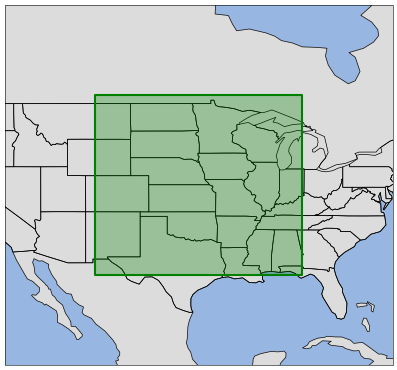

In [3]:
resolution = '110m'
map_extent = [bounds[0]-10,bounds[1]+10,bounds[2]-10,bounds[3]+10]
land = cfeature.NaturalEarthFeature('physical', 'land', resolution)
ocean = cfeature.NaturalEarthFeature('physical', 'ocean', resolution)
borders = cfeature.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', resolution)
states = cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces_lakes', resolution)
proj = ccrs.PlateCarree(central_longitude=180)
box_proj = ccrs.PlateCarree(central_longitude=0)
fig = plt.figure(figsize=[10,10], dpi=50)
ax = plt.subplot(111, projection=proj)
ax.set_extent(map_extent, box_proj)
# Add land, coastlines, borders to inset
ax.add_feature(ocean, edgecolor='none', facecolor=cfeature.COLORS['water'])
ax.add_feature(land, facecolor='gainsboro', edgecolor='k')
ax.add_feature(borders, edgecolor='k', facecolor='none')
ax.add_feature(states, edgecolor='k', facecolor='none')
# Plot a box region in the inset
box = sgeom.box(minx=bounds[0], maxx=bounds[1], miny=bounds[2], maxy=bounds[3])
ax.add_geometries([box], box_proj, facecolor='none', edgecolor='g', lw=3)
ax.add_geometries([box], box_proj, facecolor='g', edgecolor='none', alpha=0.3)

## Specify input data location

In [18]:
# Sepcify directory of the MCS track stats file
rootdir = '/pscratch/sd/w/wcmca1/SCREAM-cess/'

# Specify the years
years = [2019,2020]
datetime_range = pd.to_datetime(['2019-09-01T00', '2020-09-01T00'])
# lon_bounds = [-150,-40]
# lat_bounds = [20,55]
lifetime_bounds = [4,80]

name_map1 = {'obs':'OBS', 'm1':'EAMxx-Nudged', 'm2':'EAMxx-Free'}
name_map2 = {'obs':'OBS', 'm1':'EAMxx-N', 'm2':'EAMxx-F'}

obsfiles = []
m1files = []
m2files = []
for yy in years:
    obsfiles = obsfiles + sorted(glob.glob(f'{rootdir}gpm/stats/mcs_tracks_final_{yy}*.nc'))
    m1files = m1files + sorted(glob.glob(f'{rootdir}control_nudged/stats/mcs_tracks_final_{yy}*.nc'))
    m2files = m2files + sorted(glob.glob(f'{rootdir}control_free/stats/mcs_tracks_final_{yy}*.nc'))
nyears_obs = len(obsfiles)
nyears_m1 = len(m1files)
nyears_m2 = len(m2files)
print(f'Number of years (OBS): {nyears_obs}')
print(f'Number of years (SCREAM-free): {nyears_m1}')
print(f'Number of years (SCREAM-nudged): {nyears_m2}')

# topfile = '/global/project/projectdirs/m1657/zfeng/SAAG/map_data/wrf_landmask_reg2imerg.nc'

figdir = f'/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

Number of years (OBS): 1
Number of years (SCREAM-free): 1
Number of years (SCREAM-nudged): 1
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/


In [5]:
# # Specify years to include in the statistics
# years = [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]

# # Sepcify directory of the MCS track stats file
# # rootdir = '/pscratch/sd/s/souravt/PyFLEXTRKR/TGW_MCS/HIST/'
# rootdir = '/global/cfs/cdirs/m1867/www/PyFLEXTRKR/sample_data/TGW_MCS/'
# files_obs = []
# files_m1 = []
# for yy in years:
#     files_obs = files_obs + sorted(glob.glob(f'{rootdir}OBS/stats/mcs_tracks_final_{yy}*.nc'))
#     files_m1 = files_m1 + sorted(glob.glob(f'{rootdir}WRF/stats/mcs_tracks_final_{yy}*.nc'))
# nfiles_obs = len(files_obs)
# nfiles_wrf = len(files_m1)
# print(f'Number of files (OBS): {nfiles_obs}')
# print(f'Number of files (WRF): {nfiles_wrf}')

# # Output figure directory
# # figdir = f'/global/cfs/cdirs/m2637/zfeng/TGW_MCS/figures/'
# figdir = f'/global/cfs/cdirs/m1867/www/PyFLEXTRKR/sample_data/TGW_MCS/figures/'
# os.makedirs(figdir, exist_ok=True)
# print(figdir)

In [6]:
# Read OBS data
dsobs = xr.open_mfdataset(obsfiles, concat_dim='tracks', combine='nested')
# Renumber the tracks so they are unique
ntracks_obs = dsobs.sizes['tracks']
dsobs['tracks'] = np.arange(0, ntracks_obs)
pixel_radius_obs = dsobs.attrs['pixel_radius_km']
# dsobs

In [7]:
# Read m1 data
dsm1 = xr.open_mfdataset(m1files, concat_dim='tracks', combine='nested')
# Renumber the tracks so they are unique
ntracks_m1 = dsm1.sizes['tracks']
dsm1['tracks'] = np.arange(0, ntracks_m1)
pixel_radius_m1 = dsm1.attrs['pixel_radius_km']

In [8]:
# Read m2 data
dsm2 = xr.open_mfdataset(m2files, concat_dim='tracks', combine='nested')
# Renumber the tracks so they are unique
ntracks_m2 = dsm2.sizes['tracks']
dsm2['tracks'] = np.arange(0, ntracks_m2)
pixel_radius_m2 = dsm2.attrs['pixel_radius_km']

## Custom functions for track selections

In [9]:
def find_track_in_region(start_basetime, lons, lats, lifetime, lon_bounds, lat_bounds, lifetime_bounds, smonth_vals):
    """
    Find tracks within a region, lifetime, and month bounds.
    """
    # Get the track initiation month and location
    start_month = start_basetime.dt.month
    start_lon = lons.isel(times=0)
    start_lat = lats.isel(times=0)

    # Find tracks that initiates within a region
    mcsidx = np.where(
        (start_lon >= min(lon_bounds)) & (start_lon <= max(lon_bounds)) & \
        (start_lat >= min(lat_bounds)) & (start_lat <= max(lat_bounds)) & \
        (lifetime >= min(lifetime_bounds)) & (lifetime <= max(lifetime_bounds)) & \
        (start_basetime >= min(datetime_range)) & (start_basetime <= max(datetime_range)) & \
        (np.in1d(start_month, smonth_vals))
    )[0]
    return mcsidx

def get_land_ocean_ds(ds, trackidx, land_frac_thresh, ocean_frac_thresh):
    """
    Separate land vs. ocean tracks in Datasets.
    """
    # Subset tracks from Dataset
    ds = ds.isel(tracks=trackidx)

    # Calculate lifetime-mean PF land fraction
    init_landfrac = ds['pf_landfrac'].isel(times=slice(0,3)).mean(dim='times').compute()
    avg_landfrac = ds['pf_landfrac'].mean(dim='times').compute()
    # Separate land vs. ocean tracks
    mcsidx_land = np.where(avg_landfrac > land_frac_thresh)[0]
    mcsidx_ocean = np.where(avg_landfrac < ocean_frac_thresh)[0]
    # Subset tracks for land vs. ocean
    ds_l = ds.isel(tracks=mcsidx_land)
    ds_o = ds.isel(tracks=mcsidx_ocean)    
    return (ds_l, ds_o)

def find_merge_split_tracks(ds):
    """
    Find merge/split track indices.
    """
    # non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber)
    # non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber)
    # non-merge and non-split tracks
    idx_nms = np.isnan(ds.start_split_cloudnumber) & np.isnan(ds.end_merge_cloudnumber)
    # merge or split tracks
    idx_ms = ~np.isnan(ds.start_split_cloudnumber) | ~np.isnan(ds.end_merge_cloudnumber)
    # Group outputs to dictionary
    out_dict = {
        'ms': idx_ms.compute(),
        'nms': idx_nms.compute(),
        'nm': idx_nmerge.compute(),
        'ns': idx_nsplit.compute(),
    }
    return out_dict

## Subset tracks within a region and months

In [10]:
# Get time resolution of data
time_res_obs = dsobs.attrs['time_resolution_hour']
time_res_m1 = dsm1.attrs['time_resolution_hour']
time_res_m2 = dsm2.attrs['time_resolution_hour']
# Convert track duration to physical lifetime
lifetime_obs = dsobs.track_duration * time_res_obs
lifetime_m1 = dsm1.track_duration * time_res_obs
lifetime_m2 = dsm2.track_duration * time_res_obs

# Subset MCS by region and lifetime
lon_bounds = [bounds[0],bounds[1]]
lat_bounds = [bounds[2],bounds[3]]
# lon_bounds, lat_bounds
mcsidx_obs = find_track_in_region(dsobs.start_basetime, dsobs.meanlon, dsobs.meanlat, lifetime_obs, lon_bounds, lat_bounds, lifetime_bounds, months)
print(f'Number of tracks (OBS): {len(mcsidx_obs)}')
mcsidx_m1 = find_track_in_region(dsm1.start_basetime, dsm1.meanlon, dsm1.meanlat, lifetime_m1, lon_bounds, lat_bounds, lifetime_bounds, months)
print(f'Number of tracks (m1): {len(mcsidx_m1)}')
mcsidx_m2 = find_track_in_region(dsm2.start_basetime, dsm2.meanlon, dsm2.meanlat, lifetime_m2, lon_bounds, lat_bounds, lifetime_bounds, months)
print(f'Number of tracks (m2): {len(mcsidx_m2)}')

Number of tracks (OBS): 357
Number of tracks (m1): 352
Number of tracks (m2): 393


In [11]:
months, lon_bounds, lat_bounds, lifetime_bounds

([3, 4, 5, 6, 7, 8, 9, 10], [-108, -85], [30, 50], [4, 80])

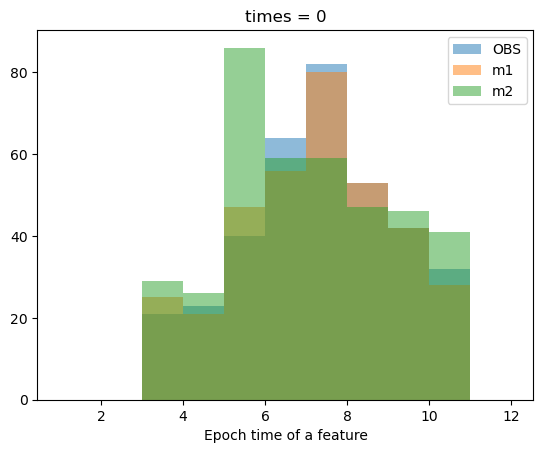

In [12]:
# Check the distribution of tracks by month
dsobs.base_time.dt.month.isel(tracks=mcsidx_obs, times=0).plot.hist(bins=np.arange(1,13,1), alpha=0.5, label='OBS')
dsm1.base_time.dt.month.isel(tracks=mcsidx_m1, times=0).plot.hist(bins=np.arange(1,13,1), alpha=0.5, label='m1')
dsm2.base_time.dt.month.isel(tracks=mcsidx_m2, times=0).plot.hist(bins=np.arange(1,13,1), alpha=0.5, label='m2')
plt.legend()

## Calculate mean/std of the number of MCSs by month
- Requires at least 3 years of data

In [13]:
# nyears, years

In [14]:
# Get start basetime for the tracks
start_basetime_obs = dsobs.base_time.isel(tracks=mcsidx_obs, times=0).compute()
start_basetime_m1 = dsm1.base_time.isel(tracks=mcsidx_m1, times=0).compute()
start_basetime_m2 = dsm2.base_time.isel(tracks=mcsidx_m2, times=0).compute()

nmonths = len(months)
nyears = len(years)
nmcs_month_avg_obs = np.ndarray(nmonths, dtype=np.float32)
# nmcs_month_std_obs = np.ndarray(nmonths, dtype=np.float32)
nmcs_month_avg_m1 = np.ndarray(nmonths, dtype=np.float32)
nmcs_month_avg_m2 = np.ndarray(nmonths, dtype=np.float32)
# nmcs_month_std_m1 = np.ndarray(nmonths, dtype=np.float32)

# Loop over each month
for im in range(0, nmonths):
    # Find startyear with the same months
    syear_obs_tmp = start_basetime_obs.dt.year.where(start_basetime_obs.dt.month == months[im], drop=True)
    syear_m1_tmp = start_basetime_m1.dt.year.where(start_basetime_m1.dt.month == months[im], drop=True)
    syear_m2_tmp = start_basetime_m2.dt.year.where(start_basetime_m2.dt.month == months[im], drop=True)

    # Make a temporary array to count the number
    count_obs = np.ndarray(nyears, dtype=np.float32)
    count_m1 = np.ndarray(nyears, dtype=np.float32)
    count_m2 = np.ndarray(nyears, dtype=np.float32)

    # Loop over each year and save the count
    for iy in range(0, nyears):
        count_obs[iy] = syear_obs_tmp.where(syear_obs_tmp == years[iy], drop=True).count()
        count_m1[iy] = syear_m1_tmp.where(syear_m1_tmp == years[iy], drop=True).count()
        count_m2[iy] = syear_m2_tmp.where(syear_m2_tmp == years[iy], drop=True).count()

    # Calculate average/std of counts for each month
    nmcs_month_avg_obs[im] = np.nanmean(count_obs)
    # nmcs_month_std_obs[im] = np.nanstd(count_obs)
    nmcs_month_avg_m1[im] = np.nanmean(count_m1)
    nmcs_month_avg_m2[im] = np.nanmean(count_m2)
    # nmcs_month_std_m1[im] = np.nanstd(count_m1)

## MCS Seasonal Cycle Counts

In [15]:
def get_month_names(month_numbers):
    """
    Get month names based on list of month numbers
    """
    month_dict = {
        1: 'Jan',
        2: 'Feb',
        3: 'Mar',
        4: 'Apr',
        5: 'May',
        6: 'Jun',
        7: 'Jul',
        8: 'Aug',
        9: 'Sep',
        10: 'Oct',
        11: 'Nov',
        12: 'Dec'
    }
    month_names = []
    for month_number in month_numbers:
        month_name = month_dict.get(month_number)
        month_names.append(month_name)
    return month_names

In [16]:
# {min(years)}-{max(years)}
year_range = f"{datetime_range.min().strftime('%Y')}-{datetime_range.max().strftime('%Y')}"
year_range

'2019-2020'

/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/mcs_number_bymonth_obs_scream.png


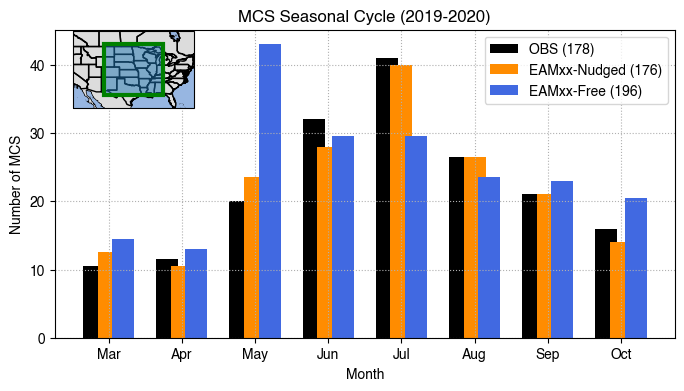

In [20]:
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['font.weight'] = 'regular'
fig = plt.figure(figsize=[8,4], dpi=100)
ax = plt.subplot()
width = 0.3
bcolors = {'obs':'k', 'm1':'darkorange', 'm2':'royalblue'}
ax.bar(np.array(months)-0.2, nmcs_month_avg_obs, width, color=bcolors['obs'], yerr=None, capsize=4, label=f"{name_map1['obs']} ({np.sum(nmcs_month_avg_obs):.0f})")
ax.bar(np.array(months)+0., nmcs_month_avg_m1, width, color=bcolors['m1'], yerr=None, capsize=4, label=f"{name_map1['m1']} ({np.sum(nmcs_month_avg_m1):.0f})")
ax.bar(np.array(months)+0.2, nmcs_month_avg_m2, width, color=bcolors['m2'], yerr=None, capsize=4, label=f"{name_map1['m2']} ({np.sum(nmcs_month_avg_m2):.0f})")

ax.legend()
ax.set_xlabel('Month', fontweight='regular')
ax.set_ylabel('Number of MCS', fontweight='regular')
ax.set_title(f'MCS Seasonal Cycle ({year_range})', fontweight='regular')
ax.grid(True, which='major', ls='dotted')
# ax.set_ylim(0,80)
# ax.set_yticks(np.arange(0,36,5))
ax.set_xticks(months)
ax.set_xticklabels(get_month_names(months))

# Inset map settings
map_extent = [lon_bounds[0]-12,lon_bounds[1]+12,lat_bounds[0]-5,lat_bounds[1]+5]
lonbox = [lon_bounds[0], lon_bounds[1]-1]
latbox = [lat_bounds[0], lat_bounds[1]]
inset_param = {'width':'25%', 'height':'25%', 'loc':'upper left', 'borderpad':0.1}
map_extent, lonbox, latbox

resolution = '50m'
land = cfeature.NaturalEarthFeature('physical', 'land', resolution)
ocean = cfeature.NaturalEarthFeature('physical', 'ocean', resolution)
states = cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces_lakes', resolution)
proj = ccrs.PlateCarree(central_longitude=0)
box_proj = ccrs.PlateCarree(central_longitude=0)
sub_ax = inset_axes(ax, width=inset_param['width'], height=inset_param['height'], loc=inset_param['loc'],
                    axes_class=cartopy.mpl.geoaxes.GeoAxes, borderpad=inset_param['borderpad'], 
                    axes_kwargs=dict(projection=proj))
sub_ax.set_extent(map_extent, box_proj)
# Add land, coastlines, borders to inset
sub_ax.add_feature(land, facecolor='gainsboro', edgecolor='k')
sub_ax.add_feature(ocean, edgecolor='none', facecolor=cfeature.COLORS['water'])
sub_ax.add_feature(states, edgecolor='k', facecolor='none', zorder=4)
# Define the vertices of the rectangle in the projection coordinates
x1, y1 = proj.transform_point(lon_bounds[0], lat_bounds[0], proj)
x2, y2 = proj.transform_point(lon_bounds[1], lat_bounds[1], proj)
# Plot rectangle
sub_ax.add_patch(mpl.patches.Rectangle((x1, y1), x2-x1, y2-y1, transform=proj, fill=None, lw=3, edgecolor='g', zorder=10))
sub_ax.add_patch(mpl.patches.Rectangle((x1, y1), x2-x1, y2-y1, transform=proj, fill='g', edgecolor=None, alpha=0.5, zorder=9))

figname = f'{figdir}mcs_number_bymonth_obs_scream.png'
fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
print(figname)

## Separate land vs. ocean MCS

In [21]:
# Separate land vs. ocean MCS
ds_l_obs, ds_o_obs = get_land_ocean_ds(dsobs, mcsidx_obs, land_frac_thresh, ocean_frac_thresh)
print(f"Number of land MCS (OBS): {ds_l_obs.sizes['tracks']}")
#print(f"Number of land MCS (OBS): {ds_l_obs.sizes['tracks']}, Number of ocean MCS (OBS): {ds_o_obs.sizes['tracks']}")

# Separate land vs. ocean MCS
ds_l_m1, ds_o_m1 = get_land_ocean_ds(dsm1, mcsidx_m1, land_frac_thresh, ocean_frac_thresh)
print(f"Number of land MCS (m1): {ds_l_m1.sizes['tracks']}")
#print(f"Number of land MCS (m1): {ds_l_m1.sizes['tracks']}, Number of ocean MCS (m1): {ds_o_m1.sizes['tracks']}")

# Separate land vs. ocean MCS
ds_l_m2, ds_o_m2 = get_land_ocean_ds(dsm2, mcsidx_m2, land_frac_thresh, ocean_frac_thresh)
print(f"Number of land MCS (m2): {ds_l_m2.sizes['tracks']}")
#print(f"Number of land MCS (m2): {ds_l_m2.sizes['tracks']}, Number of ocean MCS (m2): {ds_o_m2.sizes['tracks']}")

Number of land MCS (OBS): 291
Number of land MCS (m1): 307
Number of land MCS (m2): 345


In [22]:
ds_l_m2.track_duration.max().values

array(69, dtype=int32)

## Find merge/split track indices

In [23]:
# tid_l_obs = find_merge_split_tracks(dsobs)
# tid_l_m1 = find_merge_split_tracks(dsm1)
# tid_l_m2 = find_merge_split_tracks(dsm2)

tid_l_obs = find_merge_split_tracks(ds_l_obs)
tid_l_m1 = find_merge_split_tracks(ds_l_m1)
tid_l_m2 = find_merge_split_tracks(ds_l_m2)

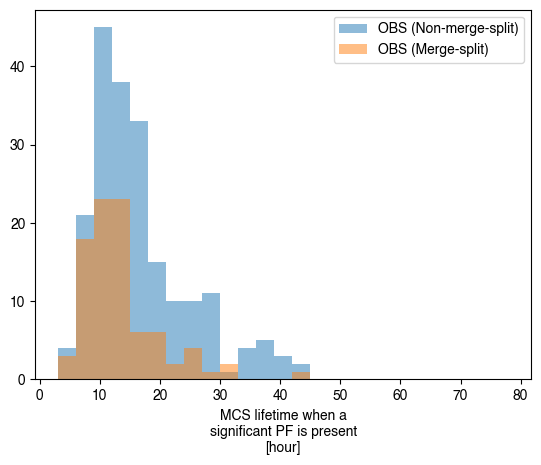

In [24]:
bins = np.arange(3,80.1,3)
ds_l_obs.isel(tracks=tid_l_obs['nms']).pf_lifetime.plot.hist(bins=bins, alpha=0.5, label='OBS (Non-merge-split)')
ds_l_obs.isel(tracks=tid_l_obs['ms']).pf_lifetime.plot.hist(bins=bins, alpha=0.5, label='OBS (Merge-split)')
plt.legend()

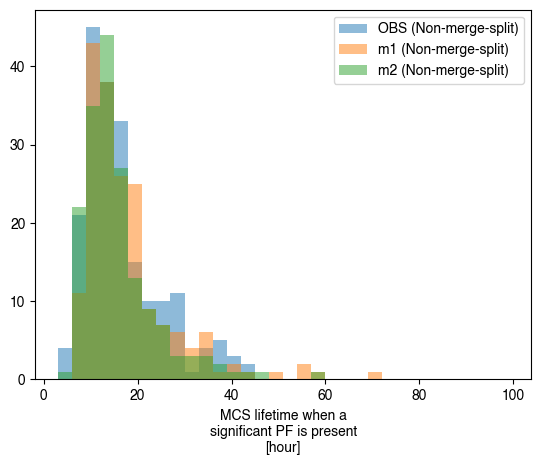

In [25]:
bins = np.arange(3,100.1,3)
ds_l_obs.isel(tracks=tid_l_obs['nms']).pf_lifetime.plot.hist(bins=bins, alpha=0.5, label='OBS (Non-merge-split)')
ds_l_m1.isel(tracks=tid_l_m1['nms']).pf_lifetime.plot.hist(bins=bins, alpha=0.5, label='m1 (Non-merge-split)')
ds_l_m2.isel(tracks=tid_l_m2['nms']).pf_lifetime.plot.hist(bins=bins, alpha=0.5, label='m2 (Non-merge-split)')
plt.legend()

In [26]:
# dsobs.where(dsobs.start_basetime.compute().dt.season == 'JJA', drop=True)

## Subset merge/split tracks

In [27]:
ds_nms_l_obs = ds_l_obs.isel(tracks=tid_l_obs['nms'])
ds_ms_l_obs = ds_l_obs.isel(tracks=tid_l_obs['ms'])
print(f"Number of non-merge-split tracks OBS (Land): {ds_nms_l_obs.sizes['tracks']}")
print(f"Number of merge-split tracks OBS (Land): {ds_ms_l_obs.sizes['tracks']}")

Number of non-merge-split tracks OBS (Land): 202
Number of merge-split tracks OBS (Land): 89


In [28]:
ds_nms_l_m1 = ds_l_m1.isel(tracks=tid_l_m1['nms'])
ds_ms_l_m1 = ds_l_m1.isel(tracks=tid_l_m1['ms'])
print(f"Number of non-merge-split tracks m1 (Land): {ds_nms_l_m1.sizes['tracks']}")
print(f"Number of merge-split tracks m1 (Land): {ds_ms_l_m1.sizes['tracks']}")

Number of non-merge-split tracks m1 (Land): 184
Number of merge-split tracks m1 (Land): 123


In [29]:
ds_nms_l_m2 = ds_l_m2.isel(tracks=tid_l_m2['nms'])
ds_ms_l_m2 = ds_l_m2.isel(tracks=tid_l_m2['ms'])
print(f"Number of non-merge-split tracks m2 (Land): {ds_nms_l_m2.sizes['tracks']}")
print(f"Number of merge-split tracks m2 (Land): {ds_ms_l_m2.sizes['tracks']}")

Number of non-merge-split tracks m2 (Land): 173
Number of merge-split tracks m2 (Land): 172


## Function to compute 1D KDE

In [30]:
def get_kde1d(data, bins, kde_bw, kde_kernel='gaussian'):
    """
    Compute 1D KDE using Ski-learn
    
    Args:
        data: np.array
            Array containing data.
        bins: np.array
            Desired bins for plotting.
        kde_bw: float
            The bandwidth of the kernel.
        kde_kernel: string
            The kernel to use.
            
    Return:
        kde_out: np.array
            KDE at the desired bins.
    """
    # Flatten array to 1D
    data1d = data.flatten()
    # Remove NaN (sklearn KDE does not handle NaN), and make a new axis
    _data = data1d[~np.isnan(data1d)][:, np.newaxis]
    _bins = bins[:, np.newaxis]
    
    # Estimate 1D KDE following sklearn example
    # https://scikit-learn.org/stable/auto_examples/neighbors/plot_kde_1d.html
    kde = KernelDensity(kernel=kde_kernel, bandwidth=kde_bw).fit(_data)
    # Get KDE values based on input bins
    log_dens = kde.score_samples(_bins)
    # Get linear density
    kde_out = np.exp(log_dens)
    return kde_out

In [31]:
# Get track start season (e.g., MAM, JJA, SON, DJF)
start_season_obs = ds_nms_l_obs.start_basetime.dt.season.compute()
start_season_m1 = ds_nms_l_m1.start_basetime.dt.season.compute()
start_season_m2 = ds_nms_l_m2.start_basetime.dt.season.compute()

### CCS Lifetime

In [32]:
time_res_obs, time_res_m1, time_res_m2

(1.0, 1.0, 1.0)

In [33]:
lifetime_bins = np.linspace(0, 60, 1000)
# Get CCS lifetime by season
ccslifetime_nms_l_obs_MAM = (ds_nms_l_obs.track_duration.where(start_season_obs == 'MAM', drop=True) * time_res_obs).compute()
ccslifetime_nms_l_m1_MAM = (ds_nms_l_m1.track_duration.where(start_season_m1 == 'MAM', drop=True) * time_res_m1).compute()
ccslifetime_nms_l_m2_MAM = (ds_nms_l_m2.track_duration.where(start_season_m2 == 'MAM', drop=True) * time_res_m2).compute()
ccslifetime_nms_l_obs_JJA = (ds_nms_l_obs.track_duration.where(start_season_obs == 'JJA', drop=True) * time_res_obs).compute()
ccslifetime_nms_l_m1_JJA = (ds_nms_l_m1.track_duration.where(start_season_m1 == 'JJA', drop=True) * time_res_m1).compute()
ccslifetime_nms_l_m2_JJA = (ds_nms_l_m2.track_duration.where(start_season_m2 == 'JJA', drop=True) * time_res_m2).compute()
# # By season
# kde_ccslifetime_nms_l_obs_MAM = get_kde1d(ccslifetime_nms_l_obs_MAM.data, lifetime_bins, kde_bw=3)
# kde_ccslifetime_nms_l_m1_MAM = get_kde1d(ccslifetime_nms_l_m1_MAM.data, lifetime_bins, kde_bw=3)
# kde_ccslifetime_nms_l_obs_JJA = get_kde1d(ccslifetime_nms_l_obs_JJA.data, lifetime_bins, kde_bw=3)
# kde_ccslifetime_nms_l_m1_JJA = get_kde1d(ccslifetime_nms_l_m1_JJA.data, lifetime_bins, kde_bw=3)

# # All season
# kde_ccslifetime_nms_l_obs = get_kde1d((ds_nms_l_obs.track_duration * time_res_obs).data, lifetime_bins, kde_bw=3)
# kde_ccslifetime_nms_l_m1 = get_kde1d((ds_nms_l_m1.track_duration * time_res_m1).data, lifetime_bins, kde_bw=3)

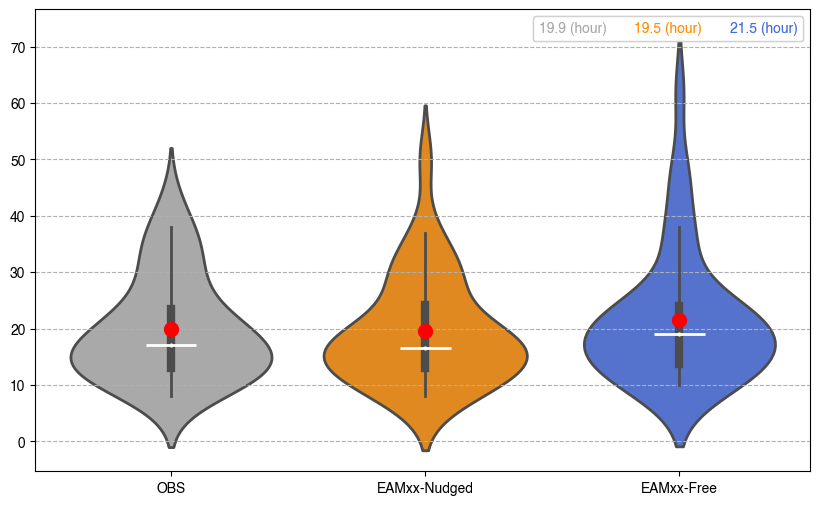

In [36]:
data = [ccslifetime_nms_l_obs_MAM.values, ccslifetime_nms_l_m1_MAM.values, ccslifetime_nms_l_m2_MAM.values]
avg1 = ccslifetime_nms_l_obs_MAM.mean().values
avg2 = ccslifetime_nms_l_m1_MAM.mean().values
avg3 = ccslifetime_nms_l_m2_MAM.mean().values
med1 = ccslifetime_nms_l_obs_MAM.median().values
med2 = ccslifetime_nms_l_m1_MAM.median().values
med3 = ccslifetime_nms_l_m2_MAM.median().values

lcolors = {'obs':'darkgray', 'm1':'darkorange', 'm2':'royalblue'}
palette = list(lcolors.values())
lw_kde = 2
color_avg = 'red'
color_med = 'white'
xlabels = list(name_map1.values())
leg_fontsize = None
leg_units = 'hour'

fig, ax = plt.subplots(1,1,figsize=(10,6),dpi=100)
data[0]
vp = sns.violinplot(data=data, ax=ax, palette=palette, linewidth=lw_kde)
# Plot median value as line
ax.hlines(med1, -0.1, 0.1, lw=2, color=color_med, zorder=4)
ax.hlines(med2, 0.9, 1.1, lw=2, color=color_med, zorder=4)
ax.hlines(med3, 1.9, 2.1, lw=2, color=color_med, zorder=4)
# Plot mean value as circle
ax.scatter(0, avg1, color=color_avg, s=100, zorder=3)
ax.scatter(1, avg2, color=color_avg, s=100, zorder=3)
ax.scatter(2, avg3, color=color_avg, s=100, zorder=3)
ax.grid(ls='--', axis='y')
ax.set_xticklabels(xlabels)
# ax.set_ylabel(ylabel)

legend_avg = [mpl.lines.Line2D([0], [0], color=lcolors['obs'], ls='none', label=f'{avg1:.1f}'+f' ({leg_units})'),
              mpl.lines.Line2D([0], [0], color=lcolors['m1'], ls='none', label=f'{avg2:.1f}'+f' ({leg_units})'),
              mpl.lines.Line2D([0], [0], color=lcolors['m2'], ls='none', label=f'{avg3:.1f}'+f' ({leg_units})'),]
legend = ax.legend(handles=legend_avg, handlelength=0, handletextpad=0, loc='best', fontsize=leg_fontsize, labelcolor='linecolor', ncol=3)
ax.add_artist(legend)

In [37]:
# fig, axes = plt.subplots(2, 1, figsize=[5,4], dpi=100, sharex=True)
# ax = axes[0]
# ax.plot(lifetime_bins, kde_ccslifetime_nms_l_obs_MAM, 'steelblue', label='OBS (MAM)')
# ax.plot(lifetime_bins, kde_ccslifetime_nms_l_m1_MAM, 'darkorange', label='WRF (MAM)')
# ax.legend()
# ax = axes[1]
# ax.plot(lifetime_bins, kde_ccslifetime_nms_l_obs_JJA, 'steelblue', label='OBS (JJA)')
# ax.plot(lifetime_bins, kde_ccslifetime_nms_l_m1_JJA, 'darkorange', label='WRF (JJA)')
# ax.invert_yaxis()
# ax.legend()
# ax.set_xlabel('CCS Lifetime (hour)')
# fig.subplots_adjust(hspace=0)

### PF Lifetime

In [38]:
# Get PF lifetime by season
pflifetime_nms_l_obs_MAM = (ds_nms_l_obs.pf_lifetime.where(start_season_obs == 'MAM', drop=True)).compute()
pflifetime_nms_l_m1_MAM = (ds_nms_l_m1.pf_lifetime.where(start_season_m1 == 'MAM', drop=True)).compute()
pflifetime_nms_l_m2_MAM = (ds_nms_l_m2.pf_lifetime.where(start_season_m2 == 'MAM', drop=True)).compute()

pflifetime_nms_l_obs_JJA = (ds_nms_l_obs.pf_lifetime.where(start_season_obs == 'JJA', drop=True)).compute()
pflifetime_nms_l_m1_JJA = (ds_nms_l_m1.pf_lifetime.where(start_season_m1 == 'JJA', drop=True)).compute()
pflifetime_nms_l_m2_JJA = (ds_nms_l_m2.pf_lifetime.where(start_season_m2 == 'JJA', drop=True)).compute()
# # By season
# kde_pflifetime_nms_l_obs_MAM = get_kde1d(pflifetime_nms_l_obs_MAM.data, lifetime_bins, kde_bw=3)
# kde_pflifetime_nms_l_m1_MAM = get_kde1d(pflifetime_nms_l_m1_MAM.data, lifetime_bins, kde_bw=3)
# kde_pflifetime_nms_l_obs_JJA = get_kde1d(pflifetime_nms_l_obs_JJA.data, lifetime_bins, kde_bw=3)
# kde_pflifetime_nms_l_m1_JJA = get_kde1d(pflifetime_nms_l_m1_JJA.data, lifetime_bins, kde_bw=3)

# # All season
# kde_pflifetime_nms_l_obs = get_kde1d(ds_nms_l_obs.pf_lifetime.data, lifetime_bins, kde_bw=3)
# kde_pflifetime_nms_l_m1 = get_kde1d(ds_nms_l_m1.pf_lifetime.data, lifetime_bins, kde_bw=3)

In [39]:
# fig, axes = plt.subplots(2, 1, figsize=[5,4], dpi=100, sharex=True)
# ax = axes[0]
# ax.plot(lifetime_bins, kde_pflifetime_nms_l_obs_MAM, 'steelblue', label='OBS (MAM)')
# ax.plot(lifetime_bins, kde_pflifetime_nms_l_m1_MAM, 'darkorange', label='WRF (MAM)')
# ax.legend()
# ax = axes[1]
# ax.plot(lifetime_bins, kde_pflifetime_nms_l_obs_JJA, 'steelblue', label='OBS (JJA)')
# ax.plot(lifetime_bins, kde_pflifetime_nms_l_m1_JJA, 'darkorange', label='WRF (JJA)')
# ax.invert_yaxis()
# ax.legend()
# ax.set_xlabel('PF Lifetime (hour)')
# fig.subplots_adjust(hspace=0)

### Max CCS Area

In [40]:
ccsarea_bins = np.linspace(4, 6.8, 1000)
# Add mergers/splits to get total CCS area
ccsarea_l_obs = ds_nms_l_obs.ccs_area + ds_nms_l_obs.merge_ccs_area.sum(dim='mergers') + ds_nms_l_obs.split_ccs_area.sum(dim='mergers')
maxccsarea_l_obs = ccsarea_l_obs.max(dim='times').compute()
ccsarea_l_m1 = ds_nms_l_m1.ccs_area + ds_nms_l_m1.merge_ccs_area.sum(dim='mergers') + ds_nms_l_m1.split_ccs_area.sum(dim='mergers')
maxccsarea_l_m1 = ccsarea_l_m1.max(dim='times').compute()
ccsarea_l_m2 = ds_nms_l_m2.ccs_area + ds_nms_l_m2.merge_ccs_area.sum(dim='mergers') + ds_nms_l_m2.split_ccs_area.sum(dim='mergers')
maxccsarea_l_m2 = ccsarea_l_m2.max(dim='times').compute()
# By season
log10maxccsarea_nms_l_obs_MAM = np.log10(maxccsarea_l_obs.where(start_season_obs == 'MAM', drop=True))
log10maxccsarea_nms_l_m1_MAM = np.log10(maxccsarea_l_m1.where(start_season_m1 == 'MAM', drop=True))
log10maxccsarea_nms_l_m2_MAM = np.log10(maxccsarea_l_m2.where(start_season_m2 == 'MAM', drop=True))

log10maxccsarea_nms_l_obs_JJA = np.log10(maxccsarea_l_obs.where(start_season_obs == 'JJA', drop=True))
log10maxccsarea_nms_l_m1_JJA = np.log10(maxccsarea_l_m1.where(start_season_m1 == 'JJA', drop=True))
log10maxccsarea_nms_l_m2_JJA = np.log10(maxccsarea_l_m2.where(start_season_m2 == 'JJA', drop=True))

# kde_maxccsarea_nms_l_obs_MAM = get_kde1d(np.log10(maxccsarea_l_obs_MAM.data), ccsarea_bins, kde_bw=0.2)
# kde_maxccsarea_nms_l_m1_MAM = get_kde1d(np.log10(maxccsarea_l_m1_MAM.data), ccsarea_bins, kde_bw=0.2)
# kde_maxccsarea_nms_l_obs_JJA = get_kde1d(np.log10(maxccsarea_l_obs_JJA.data), ccsarea_bins, kde_bw=0.2)
# kde_maxccsarea_nms_l_m1_JJA = get_kde1d(np.log10(maxccsarea_l_m1_JJA.data), ccsarea_bins, kde_bw=0.2)

# # All season
# kde_maxccsarea_nms_l_obs = get_kde1d(np.log10(maxccsarea_l_obs.data), ccsarea_bins, kde_bw=0.2)
# kde_maxccsarea_nms_l_m1 = get_kde1d(np.log10(maxccsarea_l_m1.data), ccsarea_bins, kde_bw=0.2)

In [41]:
# fig, axes = plt.subplots(2, 1, figsize=[5,4], dpi=100, sharex=True)
# ax = axes[0]
# ax.plot(ccsarea_bins, kde_maxccsarea_nms_l_obs_MAM, 'steelblue', label='OBS (MAM)')
# ax.plot(ccsarea_bins, kde_maxccsarea_nms_l_m1_MAM, 'darkorange', label='WRF (MAM)')
# ax.legend()
# ax = axes[1]
# ax.plot(ccsarea_bins, kde_maxccsarea_nms_l_obs_JJA, 'steelblue', label='OBS (JJA)')
# ax.plot(ccsarea_bins, kde_maxccsarea_nms_l_m1_JJA, 'darkorange', label='WRF (JJA)')
# ax.invert_yaxis()
# ax.legend()
# ax.set_xlabel('Log$_{10}$(Max CCS Area (km$^2$))')
# fig.subplots_adjust(hspace=0)

### Lifetime-average min Tb

In [42]:
avgmintb_nms_l_obs_MAM = ds_nms_l_obs.corecold_mintb.where(start_season_obs == 'MAM', drop=True).mean(dim='times').compute()
avgmintb_nms_l_m1_MAM = ds_nms_l_m1.corecold_mintb.where(start_season_m1 == 'MAM', drop=True).mean(dim='times').compute()
avgmintb_nms_l_m2_MAM = ds_nms_l_m2.corecold_mintb.where(start_season_m2 == 'MAM', drop=True).mean(dim='times').compute()

avgmintb_nms_l_obs_JJA = ds_nms_l_obs.corecold_mintb.where(start_season_obs == 'JJA', drop=True).mean(dim='times').compute()
avgmintb_nms_l_m1_JJA = ds_nms_l_m1.corecold_mintb.where(start_season_m1 == 'JJA', drop=True).mean(dim='times').compute()
avgmintb_nms_l_m2_JJA = ds_nms_l_m2.corecold_mintb.where(start_season_m2 == 'JJA', drop=True).mean(dim='times').compute()

In [43]:
# avgmintb_bins = np.linspace(200, 240, 1000)
# # By season
# kde_avgmintb_nms_l_obs_MAM = get_kde1d(ds_nms_l_obs.corecold_mintb.where(start_season_obs == 'MAM', drop=True).mean(dim='times').data, avgmintb_bins, kde_bw=2)
# kde_avgmintb_nms_l_m1_MAM = get_kde1d(ds_nms_l_m1.corecold_mintb.where(start_season_m1 == 'MAM', drop=True).mean(dim='times').data, avgmintb_bins, kde_bw=2)
# kde_avgmintb_nms_l_obs_JJA = get_kde1d(ds_nms_l_obs.corecold_mintb.where(start_season_obs == 'JJA', drop=True).mean(dim='times').data, avgmintb_bins, kde_bw=2)
# kde_avgmintb_nms_l_m1_JJA = get_kde1d(ds_nms_l_m1.corecold_mintb.where(start_season_m1 == 'JJA', drop=True).mean(dim='times').data, avgmintb_bins, kde_bw=2)

# # Land
# kde_avgmintb_nms_l_obs = get_kde1d(ds_nms_l_obs.corecold_mintb.mean(dim='times').data, avgmintb_bins, kde_bw=2)
# kde_avgmintb_nms_l_m1 = get_kde1d(ds_nms_l_m1.corecold_mintb.mean(dim='times').data, avgmintb_bins, kde_bw=2)

In [44]:
# fig, axes = plt.subplots(2, 1, figsize=[5,4], dpi=100, sharex=True)
# ax = axes[0]
# ax.plot(avgmintb_bins, kde_avgmintb_nms_l_obs_MAM, 'steelblue', label='OBS (MAM)')
# ax.plot(avgmintb_bins, kde_avgmintb_nms_l_m1_MAM, 'darkorange', label='WRF (MAM)')
# ax.legend()
# ax = axes[1]
# ax.plot(avgmintb_bins, kde_avgmintb_nms_l_obs_JJA, 'steelblue', label='OBS (JJA)')
# ax.plot(avgmintb_bins, kde_avgmintb_nms_l_m1_JJA, 'darkorange', label='WRF (JJA)')
# ax.invert_yaxis()
# ax.legend()
# ax.set_xlabel('Lifetime-Mean Min Tb (K)')
# fig.subplots_adjust(hspace=0)

### Lifetime-min Min Tb

In [45]:
# mintb_bins = np.linspace(190, 230, 1000)
# # By season
# kde_mintb_nms_l_obs_MAM = get_kde1d(ds_nms_l_obs.corecold_mintb.where(start_season_obs == 'MAM', drop=True).min(dim='times').data, mintb_bins, kde_bw=2)
# kde_mintb_nms_l_m1_MAM = get_kde1d(ds_nms_l_m1.corecold_mintb.where(start_season_m1 == 'MAM', drop=True).min(dim='times').data, mintb_bins, kde_bw=2)
# kde_mintb_nms_l_obs_JJA = get_kde1d(ds_nms_l_obs.corecold_mintb.where(start_season_obs == 'JJA', drop=True).min(dim='times').data, mintb_bins, kde_bw=2)
# kde_mintb_nms_l_m1_JJA = get_kde1d(ds_nms_l_m1.corecold_mintb.where(start_season_m1 == 'JJA', drop=True).min(dim='times').data, mintb_bins, kde_bw=2)

# # All seasons
# kde_mintb_nms_l_obs = get_kde1d(ds_nms_l_obs.corecold_mintb.min(dim='times').data, mintb_bins, kde_bw=2)
# kde_mintb_nms_l_m1 = get_kde1d(ds_nms_l_m1.corecold_mintb.min(dim='times').data, mintb_bins, kde_bw=2)

In [46]:
# fig, axes = plt.subplots(2, 1, figsize=[5,4], dpi=100, sharex=True)
# ax = axes[0]
# ax.plot(mintb_bins, kde_mintb_nms_l_obs_MAM, 'steelblue', label='OBS (MAM)')
# ax.plot(mintb_bins, kde_mintb_nms_l_m1_MAM, 'darkorange', label='WRF (MAM)')
# ax.legend()
# ax = axes[1]
# ax.plot(mintb_bins, kde_mintb_nms_l_obs_JJA, 'steelblue', label='OBS (JJA)')
# ax.plot(mintb_bins, kde_mintb_nms_l_m1_JJA, 'darkorange', label='WRF (JJA)')
# ax.invert_yaxis()
# ax.legend()
# ax.set_xlabel('Lifetime-Min Min Tb (K)')
# fig.subplots_adjust(hspace=0)

### Max PF Area

In [47]:
maxpfarea_l_obs = ds_nms_l_obs.pf_area.sum(dim='nmaxpf').max(dim='times').compute()
maxpfarea_l_m1 = ds_nms_l_m1.pf_area.sum(dim='nmaxpf').max(dim='times').compute()
maxpfarea_l_m2 = ds_nms_l_m2.pf_area.sum(dim='nmaxpf').max(dim='times').compute()

log10maxpfarea_l_nms_obs_MAM = np.log10(maxpfarea_l_obs.where(start_season_obs == 'MAM', drop=True))
log10maxpfarea_l_nms_m1_MAM = np.log10(maxpfarea_l_m1.where(start_season_m1 == 'MAM', drop=True))
log10maxpfarea_l_nms_m2_MAM = np.log10(maxpfarea_l_m2.where(start_season_m2 == 'MAM', drop=True))

log10maxpfarea_l_nms_obs_JJA = np.log10(maxpfarea_l_obs.where(start_season_obs == 'JJA', drop=True))
log10maxpfarea_l_nms_m1_JJA = np.log10(maxpfarea_l_m1.where(start_season_m1 == 'JJA', drop=True))
log10maxpfarea_l_nms_m2_JJA = np.log10(maxpfarea_l_m2.where(start_season_m2 == 'JJA', drop=True))

In [48]:
# pfarea_bins = np.linspace(3.3, 6.5, 1000)
# # Sum all PFs at a given time, then take max during lifetime
# # Land
# maxpfarea_l_obs = ds_nms_l_obs.pf_area.sum(dim='nmaxpf').max(dim='times')
# maxpfarea_l_m1 = ds_nms_l_m1.pf_area.sum(dim='nmaxpf').max(dim='times')
# # maxpfarea_l_obs = ds_nms_l_obs.pf_area.max(dim='nmaxpf').max(dim='times')
# # maxpfarea_l_m1 = ds_nms_l_m1.pf_area.max(dim='nmaxpf').max(dim='times')
# # By season
# kde_maxpfarea_nms_l_obs_MAM = get_kde1d(np.log10(maxpfarea_l_obs.where(start_season_obs == 'MAM', drop=True).data), pfarea_bins, kde_bw=0.2)
# kde_maxpfarea_nms_l_m1_MAM = get_kde1d(np.log10(maxpfarea_l_m1.where(start_season_obs == 'MAM', drop=True).data), pfarea_bins, kde_bw=0.2)
# kde_maxpfarea_nms_l_obs_JJA = get_kde1d(np.log10(maxpfarea_l_obs.where(start_season_obs == 'JJA', drop=True).data), pfarea_bins, kde_bw=0.2)
# kde_maxpfarea_nms_l_m1_JJA = get_kde1d(np.log10(maxpfarea_l_m1.where(start_season_obs == 'JJA', drop=True).data), pfarea_bins, kde_bw=0.2)

# # All seasons
# kde_maxpfarea_nms_l_obs = get_kde1d(np.log10(maxpfarea_l_obs.data), pfarea_bins, kde_bw=0.2)
# kde_maxpfarea_nms_l_m1 = get_kde1d(np.log10(maxpfarea_l_m1.data), pfarea_bins, kde_bw=0.2)

In [49]:
# fig, axes = plt.subplots(2, 1, figsize=[5,4], dpi=100, sharex=True)
# ax = axes[0]
# ax.plot(pfarea_bins, kde_maxpfarea_nms_l_obs_MAM, 'steelblue', label='OBS (MAM)')
# ax.plot(pfarea_bins, kde_maxpfarea_nms_l_m1_MAM, 'darkorange', label='WRF (MAM)')
# ax.legend()
# ax = axes[1]
# ax.plot(pfarea_bins, kde_maxpfarea_nms_l_obs_JJA, 'steelblue', label='OBS (JJA)')
# ax.plot(pfarea_bins, kde_maxpfarea_nms_l_m1_JJA, 'darkorange', label='WRF (JJA)')
# ax.invert_yaxis()
# ax.legend()
# ax.set_xlabel('Log$_{10}$(Max PF Area (km$^2$))')
# fig.subplots_adjust(hspace=0)

### Mean PF Rain Rate

In [50]:
meanpfrainrate_nms_l_obs_MAM = ds_nms_l_obs.pf_rainrate.isel(nmaxpf=0).where(start_season_obs == 'MAM', drop=True).mean(dim='times').compute()
meanpfrainrate_nms_l_m1_MAM = ds_nms_l_m1.pf_rainrate.isel(nmaxpf=0).where(start_season_m1 == 'MAM', drop=True).mean(dim='times').compute()
meanpfrainrate_nms_l_m2_MAM = ds_nms_l_m2.pf_rainrate.isel(nmaxpf=0).where(start_season_m2 == 'MAM', drop=True).mean(dim='times').compute()

meanpfrainrate_nms_l_obs_JJA = ds_nms_l_obs.pf_rainrate.isel(nmaxpf=0).where(start_season_obs == 'JJA', drop=True).mean(dim='times').compute()
meanpfrainrate_nms_l_m1_JJA = ds_nms_l_m1.pf_rainrate.isel(nmaxpf=0).where(start_season_m1 == 'JJA', drop=True).mean(dim='times').compute()
meanpfrainrate_nms_l_m2_JJA = ds_nms_l_m2.pf_rainrate.isel(nmaxpf=0).where(start_season_m2 == 'JJA', drop=True).mean(dim='times').compute()

In [51]:
# pfrainrate_bins = np.linspace(0., 5, 1000)
# # Select the largest PF (nmaxpf=0), then take mean during lifetime
# # By season
# kde_meanpfrainrate_nms_l_obs_MAM = get_kde1d(ds_nms_l_obs.pf_rainrate.isel(nmaxpf=0).where(start_season_obs == 'MAM', drop=True).mean(dim='times').data, pfrainrate_bins, kde_bw=0.25)
# kde_meanpfrainrate_nms_l_m1_MAM = get_kde1d(ds_nms_l_m1.pf_rainrate.isel(nmaxpf=0).where(start_season_obs == 'MAM', drop=True).mean(dim='times').data, pfrainrate_bins, kde_bw=0.25)
# kde_meanpfrainrate_nms_l_obs_JJA = get_kde1d(ds_nms_l_obs.pf_rainrate.isel(nmaxpf=0).where(start_season_obs == 'JJA', drop=True).mean(dim='times').data, pfrainrate_bins, kde_bw=0.25)
# kde_meanpfrainrate_nms_l_m1_JJA = get_kde1d(ds_nms_l_m1.pf_rainrate.isel(nmaxpf=0).where(start_season_obs == 'JJA', drop=True).mean(dim='times').data, pfrainrate_bins, kde_bw=0.25)

# # Land
# kde_meanpfrainrate_nms_l_obs = get_kde1d(ds_nms_l_obs.pf_rainrate.isel(nmaxpf=0).mean(dim='times').data, pfrainrate_bins, kde_bw=0.5)
# kde_meanpfrainrate_nms_l_m1 = get_kde1d(ds_nms_l_m1.pf_rainrate.isel(nmaxpf=0).mean(dim='times').data, pfrainrate_bins, kde_bw=0.5)

In [52]:
# fig, axes = plt.subplots(2, 1, figsize=[5,4], dpi=100, sharex=True)
# ax = axes[0]
# ax.plot(pfrainrate_bins, kde_meanpfrainrate_nms_l_obs_MAM, 'steelblue', label='OBS (MAM)')
# ax.plot(pfrainrate_bins, kde_meanpfrainrate_nms_l_m1_MAM, 'darkorange', label='WRF (MAM)')
# ax.legend()
# ax = axes[1]
# ax.plot(pfrainrate_bins, kde_meanpfrainrate_nms_l_obs_JJA, 'steelblue', label='OBS (JJA)')
# ax.plot(pfrainrate_bins, kde_meanpfrainrate_nms_l_m1_JJA, 'darkorange', label='WRF (JJA)')
# ax.invert_yaxis()
# ax.legend()
# ax.set_xlabel('Mean PF Rain Rate (mm h$^{-1}$))')
# fig.subplots_adjust(hspace=0)

### Lifetime-total Rain Volume

In [53]:
# Lifetime total rain volume [unit: kg]
pfvolrain_l_obs = (ds_nms_l_obs.total_rain.sum(dim='times') * pixel_radius_obs**2).compute()
pfvolrain_l_m1 = (ds_nms_l_m1.total_rain.sum(dim='times') * pixel_radius_m1**2).compute()
pfvolrain_l_m2 = (ds_nms_l_m2.total_rain.sum(dim='times') * pixel_radius_m2**2).compute()

log10pfvolrain_nms_l_obs_MAM = np.log10(pfvolrain_l_obs.where(start_season_obs == 'MAM', drop=True))
log10pfvolrain_nms_l_m1_MAM = np.log10(pfvolrain_l_m1.where(start_season_m1 == 'MAM', drop=True))
log10pfvolrain_nms_l_m2_MAM = np.log10(pfvolrain_l_m2.where(start_season_m2 == 'MAM', drop=True))

log10pfvolrain_nms_l_obs_JJA = np.log10(pfvolrain_l_obs.where(start_season_obs == 'JJA', drop=True))
log10pfvolrain_nms_l_m1_JJA = np.log10(pfvolrain_l_m1.where(start_season_m1 == 'JJA', drop=True))
log10pfvolrain_nms_l_m2_JJA = np.log10(pfvolrain_l_m2.where(start_season_m2 == 'JJA', drop=True))

In [54]:
# volrain_bins = np.linspace(4.5, 8.0, 1000)

# # Lifetime total rain volume [unit: kg]
# pfvolrain_l_obs = ds_nms_l_obs.total_rain.sum(dim='times') * pixel_radius_obs**2
# pfvolrain_l_m1 = ds_nms_l_m1.total_rain.sum(dim='times') * pixel_radius_m1**2
# # By season
# kde_pfvolrain_nms_l_obs_MAM = get_kde1d(np.log10(pfvolrain_l_obs.where(start_season_obs == 'MAM', drop=True).data), volrain_bins, kde_bw=0.2)
# kde_pfvolrain_nms_l_m1_MAM = get_kde1d(np.log10(pfvolrain_l_m1.where(start_season_m1 == 'MAM', drop=True).data), volrain_bins, kde_bw=0.2)
# kde_pfvolrain_nms_l_obs_JJA = get_kde1d(np.log10(pfvolrain_l_obs.where(start_season_obs == 'JJA', drop=True).data), volrain_bins, kde_bw=0.2)
# kde_pfvolrain_nms_l_m1_JJA = get_kde1d(np.log10(pfvolrain_l_m1.where(start_season_m1 == 'JJA', drop=True).data), volrain_bins, kde_bw=0.2)

# # All seasons
# kde_pfvolrain_nms_l_obs = get_kde1d(np.log10(pfvolrain_l_obs.data), volrain_bins, kde_bw=0.2)
# kde_pfvolrain_nms_l_m1 = get_kde1d(np.log10(pfvolrain_l_m1.data), volrain_bins, kde_bw=0.2)

In [55]:
# fig, axes = plt.subplots(2, 1, figsize=[5,4], dpi=100, sharex=True)
# ax = axes[0]
# ax.plot(volrain_bins, kde_pfvolrain_nms_l_obs_MAM, 'steelblue', label='OBS (MAM)')
# ax.plot(volrain_bins, kde_pfvolrain_nms_l_m1_MAM, 'darkorange', label='WRF (MAM)')
# ax.legend()
# ax = axes[1]
# ax.plot(volrain_bins, kde_pfvolrain_nms_l_obs_JJA, 'steelblue', label='OBS (JJA)')
# ax.plot(volrain_bins, kde_pfvolrain_nms_l_m1_JJA, 'darkorange', label='WRF (JJA)')
# ax.invert_yaxis()
# ax.legend()
# ax.set_xlabel('Log$_{10}$(Lifetime-total Vol. Rain (kg))')
# fig.subplots_adjust(hspace=0)

### Heavy rain volume

In [56]:
pfheavyvolrain_l_obs = (ds_nms_l_obs.total_heavyrain.sum(dim='times') * pixel_radius_obs**2).compute()
pfheavyvolrain_l_m1 = (ds_nms_l_m1.total_heavyrain.sum(dim='times') * pixel_radius_m1**2).compute()
pfheavyvolrain_l_m2 = (ds_nms_l_m2.total_heavyrain.sum(dim='times') * pixel_radius_m2**2).compute()

# log10pfheavyvolrain_l_obs_MAM = np.log10(pfheavyvolrain_l_obs.where(start_season_obs == 'MAM', drop=True))
# log10pfheavyvolrain_l_m1_MAM = np.log10(pfheavyvolrain_l_m1.where(start_season_m1 == 'MAM', drop=True))
# log10pfheavyvolrain_l_m2_MAM = np.log10(pfheavyvolrain_l_m2.where(start_season_m2 == 'MAM', drop=True))

# log10pfheavyvolrain_l_obs_JJA = np.log10(pfheavyvolrain_l_obs.where(start_season_obs == 'JJA', drop=True))
# log10pfheavyvolrain_l_m1_JJA = np.log10(pfheavyvolrain_l_m1.where(start_season_m1 == 'JJA', drop=True))
# log10pfheavyvolrain_l_m2_JJA = np.log10(pfheavyvolrain_l_m2.where(start_season_m2 == 'JJA', drop=True))

In [57]:
# # Lifetime total heavy rain volume [unit: kg]
# # Land
# pfheavyvolrain_l_obs = ds_nms_l_obs.total_heavyrain.sum(dim='times') * pixel_radius_obs**2
# pfheavyvolrain_l_m1 = ds_nms_l_m1.total_heavyrain.sum(dim='times') * pixel_radius_m1**2

# heavyvolrain_bins = np.linspace(4, 8, 1000)
# # By seasons
# kde_pfheavyvolrain_nms_l_obs_MAM = get_kde1d(np.log10(pfheavyvolrain_l_obs.where(start_season_obs == 'MAM', drop=True).data), heavyvolrain_bins, kde_bw=0.2)
# kde_pfheavyvolrain_nms_l_m1_MAM = get_kde1d(np.log10(pfheavyvolrain_l_m1.where(start_season_obs == 'MAM', drop=True).data), heavyvolrain_bins, kde_bw=0.2)
# kde_pfheavyvolrain_nms_l_obs_JJA = get_kde1d(np.log10(pfheavyvolrain_l_obs.where(start_season_obs == 'JJA', drop=True).data), heavyvolrain_bins, kde_bw=0.2)
# kde_pfheavyvolrain_nms_l_m1_JJA = get_kde1d(np.log10(pfheavyvolrain_l_m1.where(start_season_obs == 'JJA', drop=True).data), heavyvolrain_bins, kde_bw=0.2)

# # All seasons
# kde_pfheavyvolrain_nms_l_obs = get_kde1d(np.log10(pfheavyvolrain_l_obs.data), heavyvolrain_bins, kde_bw=0.2)
# kde_pfheavyvolrain_nms_l_m1 = get_kde1d(np.log10(pfheavyvolrain_l_m1.data), heavyvolrain_bins, kde_bw=0.2)

In [58]:
# fig, axes = plt.subplots(2, 1, figsize=[5,4], dpi=100, sharex=True)
# ax = axes[0]
# ax.plot(heavyvolrain_bins, kde_pfheavyvolrain_nms_l_obs_MAM, 'steelblue', label='OBS (MAM)')
# ax.plot(heavyvolrain_bins, kde_pfheavyvolrain_nms_l_m1_MAM, 'darkorange', label='WRF (MAM)')
# ax.legend()
# ax = axes[1]
# ax.plot(heavyvolrain_bins, kde_pfheavyvolrain_nms_l_obs_JJA, 'steelblue', label='OBS (JJA)')
# ax.plot(heavyvolrain_bins, kde_pfheavyvolrain_nms_l_m1_JJA, 'darkorange', label='WRF (JJA)')
# ax.invert_yaxis()
# ax.legend()
# ax.set_xlabel('Log$_{10}$(Lifetime-total Heavy Vol. Rain (kg))')
# fig.subplots_adjust(hspace=0)

### Heavy Rain Volume Ratio

In [59]:
# Heavy rain volume ratio (heavy rain vol. / total rain vol.)
pfhrr_nms_l_obs = 100 * pfheavyvolrain_l_obs / pfvolrain_l_obs
pfhrr_nms_l_m1 = 100 * pfheavyvolrain_l_m1 / pfvolrain_l_m1
pfhrr_nms_l_m2 = 100 * pfheavyvolrain_l_m2 / pfvolrain_l_m2

pfhrr_nms_l_obs_MAM = pfhrr_nms_l_obs.where(start_season_obs == 'MAM', drop=True)
pfhrr_nms_l_m1_MAM = pfhrr_nms_l_m1.where(start_season_m1 == 'MAM', drop=True)
pfhrr_nms_l_m2_MAM = pfhrr_nms_l_m2.where(start_season_m2 == 'MAM', drop=True)

pfhrr_nms_l_obs_JJA = pfhrr_nms_l_obs.where(start_season_obs == 'JJA', drop=True)
pfhrr_nms_l_m1_JJA = pfhrr_nms_l_m1.where(start_season_m1 == 'JJA', drop=True)
pfhrr_nms_l_m2_JJA = pfhrr_nms_l_m2.where(start_season_m2 == 'JJA', drop=True)

In [60]:
# # Heavy rain volume ratio (heavy rain vol. / total rain vol.)
# pfhrr_nms_l_obs = 100 * pfheavyvolrain_l_obs / pfvolrain_l_obs
# pfhrr_nms_l_m1 = 100 * pfheavyvolrain_l_m1 / pfvolrain_l_m1

# pfhrr_bins = np.linspace(0, 100, 1000)
# # By season
# kde_pfhrr_nms_l_obs_MAM = get_kde1d(pfhrr_nms_l_obs.where(start_season_obs == 'MAM', drop=True).data, pfhrr_bins, kde_bw=4)
# kde_pfhrr_nms_l_m1_MAM = get_kde1d(pfhrr_nms_l_m1.where(start_season_obs == 'MAM', drop=True).data, pfhrr_bins, kde_bw=4)
# kde_pfhrr_nms_l_obs_JJA = get_kde1d(pfhrr_nms_l_obs.where(start_season_obs == 'JJA', drop=True).data, pfhrr_bins, kde_bw=4)
# kde_pfhrr_nms_l_m1_JJA = get_kde1d(pfhrr_nms_l_m1.where(start_season_obs == 'JJA', drop=True).data, pfhrr_bins, kde_bw=4)

# # All seasons
# kde_pfhrr_nms_l_obs = get_kde1d(pfhrr_nms_l_obs.data, pfhrr_bins, kde_bw=4)
# kde_pfhrr_nms_l_m1 = get_kde1d(pfhrr_nms_l_m1.data, pfhrr_bins, kde_bw=4)

In [61]:
# fig, axes = plt.subplots(2, 1, figsize=[5,4], dpi=100, sharex=True)
# ax = axes[0]
# ax.plot(pfhrr_bins, kde_pfhrr_nms_l_obs_MAM, 'steelblue', label='OBS (MAM)')
# ax.plot(pfhrr_bins, kde_pfhrr_nms_l_m1_MAM, 'darkorange', label='WRF (MAM)')
# ax.legend()
# ax = axes[1]
# ax.plot(pfhrr_bins, kde_pfhrr_nms_l_obs_JJA, 'steelblue', label='OBS (JJA)')
# ax.plot(pfhrr_bins, kde_pfhrr_nms_l_m1_JJA, 'darkorange', label='WRF (JJA)')
# ax.invert_yaxis()
# ax.legend()
# ax.set_xlabel('Lifetime-total Heavy Rain Ratio (%)')
# fig.subplots_adjust(hspace=0)

### MCS Lifetime-median PF Movement Speed

In [62]:
pfspeed_l_obs = ds_nms_l_obs.movement_speed.median(dim='times').compute()
pfspeed_l_m1 = ds_nms_l_m1.movement_speed.median(dim='times').compute()
pfspeed_l_m2 = ds_nms_l_m2.movement_speed.median(dim='times').compute()

pfspeed_nms_l_obs_MAM = pfspeed_l_obs.where(start_season_obs == 'MAM', drop=True)
pfspeed_nms_l_m1_MAM = pfspeed_l_m1.where(start_season_m1 == 'MAM', drop=True)
pfspeed_nms_l_m2_MAM = pfspeed_l_m2.where(start_season_m2 == 'MAM', drop=True)

pfspeed_nms_l_obs_JJA = pfspeed_l_obs.where(start_season_obs == 'JJA', drop=True)
pfspeed_nms_l_m1_JJA = pfspeed_l_m1.where(start_season_m1 == 'JJA', drop=True)
pfspeed_nms_l_m2_JJA = pfspeed_l_m2.where(start_season_m2 == 'JJA', drop=True)

In [63]:
# # PF movement speed
# pfspeed_bins = np.linspace(0, 30, 1000)
# # By season
# kde_pfspeed_nms_l_obs_MAM = get_kde1d(ds_nms_l_obs.movement_speed.where(start_season_obs == 'MAM', drop=True).median(dim='times').data, pfspeed_bins, kde_bw=2)
# kde_pfspeed_nms_l_m1_MAM = get_kde1d(ds_nms_l_m1.movement_speed.where(start_season_obs == 'MAM', drop=True).median(dim='times').data, pfspeed_bins, kde_bw=2)
# kde_pfspeed_nms_l_obs_JJA = get_kde1d(ds_nms_l_obs.movement_speed.where(start_season_obs == 'JJA', drop=True).median(dim='times').data, pfspeed_bins, kde_bw=2)
# kde_pfspeed_nms_l_m1_JJA = get_kde1d(ds_nms_l_m1.movement_speed.where(start_season_obs == 'JJA', drop=True).median(dim='times').data, pfspeed_bins, kde_bw=2)

# # All seasons
# kde_pfspeed_nms_l_obs = get_kde1d(ds_nms_l_obs.movement_speed.median(dim='times').data, pfspeed_bins, kde_bw=2)
# kde_pfspeed_nms_l_m1 = get_kde1d(ds_nms_l_m1.movement_speed.median(dim='times').data, pfspeed_bins, kde_bw=2)

In [64]:
# fig, axes = plt.subplots(2, 1, figsize=[5,4], dpi=100, sharex=True)
# ax = axes[0]
# ax.plot(pfspeed_bins, kde_pfspeed_nms_l_obs_MAM, 'steelblue', label='OBS (MAM)')
# ax.plot(pfspeed_bins, kde_pfspeed_nms_l_m1_MAM, 'darkorange', label='WRF (MAM)')
# ax.legend()
# ax = axes[1]
# ax.plot(pfspeed_bins, kde_pfspeed_nms_l_obs_JJA, 'steelblue', label='OBS (JJA)')
# ax.plot(pfspeed_bins, kde_pfspeed_nms_l_m1_JJA, 'darkorange', label='WRF (JJA)')
# ax.invert_yaxis()
# ax.legend()
# ax.set_xlabel('Median PF Movement Speed (m/s)')
# fig.subplots_adjust(hspace=0)

In [66]:
def plot_mxn_violin(nrow, ncol, da, sigtest=None, ypos_sig=None, ylabels=None, ylims=None, titles=None, fontsize=None, figsize=None, figname=None,
                    xrotation=None, name_map=None, leg_fontsize=None, leg_rowcol=(0,0)):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    lcolors = {'obs':'k', 'm1':'darkorange', 'm2':'royalblue'}
    fcolors = {'obs':'darkgray', 'm1':'darkorange', 'm2':'royalblue'}
    palette = list(fcolors.values())    
    lw_kde = 2
    size_avg = 60
    color_avg = 'red'
    color_med = 'white'
    xlabels = list(name_map.values())
    # leg_fontsize = None
    # leg_units = 'dBZ'
    
    # bar_labels = list(name_map.values())
    # bar_colors = list(lcolors.values())
       
    for row in range(nrow):
        for col in range(ncol):
            ax = axes[row][col]
            violin_data = da[row][col]
            # Calculate means and medians
            avg0 = np.nanmean(violin_data[0])
            avg1 = np.nanmean(violin_data[1])
            avg2 = np.nanmean(violin_data[2])
            med0 = np.nanmedian(violin_data[0])
            med1 = np.nanmedian(violin_data[1])
            med2 = np.nanmedian(violin_data[2])
            # Violin plot
            vp = sns.violinplot(data=violin_data, ax=ax, palette=palette, linewidth=lw_kde)
            # Plot median value as line
            ax.hlines(med0, -0.1, 0.1, lw=2, color=color_med, zorder=4)
            ax.hlines(med1, 0.9, 1.1, lw=2, color=color_med, zorder=4)
            ax.hlines(med2, 1.9, 2.1, lw=2, color=color_med, zorder=4)
            # Plot mean value as circle
            ax.scatter(0, avg0, color=color_avg, s=size_avg, zorder=3)
            ax.scatter(1, avg1, color=color_avg, s=size_avg, zorder=3)
            ax.scatter(2, avg2, color=color_avg, s=size_avg, zorder=3)
            # Set plots
            ax.set_xticklabels(xlabels)
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            ax.grid(ls=':', axis='y')
            # Axis labels
            n_xlabels = len(xlabels)
            n_ylabels = len(ylabels)
            # x_centers = np.arange(0.5, n_xlabels+0.5, 1)
            # y_centers = np.arange(0.5, n_ylabels+0.5, 1)
            x_centers = np.arange(0, n_xlabels, 1)
            y_centers = np.arange(0, n_ylabels, 1)
            # if show_xlabel[row][col]:
            ax.set_xticks(x_centers, xlabels, rotation=xrotation, ha='right')
            if ylims is not None: ax.set_ylim(ylims[row][col][0], ylims[row][col][1])
            if sigtest is not None:
                ax.text(0.05, ypos_sig[row][col], sigtest[row][col]['obs'], color=color_avg, va='top', fontsize=leg_fontsize)
                ax.text(1.05, ypos_sig[row][col], sigtest[row][col]['m1'], color=color_avg, va='top', fontsize=leg_fontsize)
            # Legend
            if (row == leg_rowcol[0]) & (col == leg_rowcol[1]):
                legend_elements = [mpl.patches.Patch(facecolor=fcolors['obs'], edgecolor='k', label=f"{name_map['obs']} ({len(violin_data[0])})"),
                                   mpl.patches.Patch(facecolor=fcolors['m1'], edgecolor='k', label=f"{name_map['m1']} ({len(violin_data[1])})"),
                                   mpl.patches.Patch(facecolor=fcolors['m2'], edgecolor='k', label=f"{name_map['m2']} ({len(violin_data[2])})"),]
                # legend_avg = [mpl.lines.Line2D([0], [0], color=lcolors['obs'], ls='none', label=f'{avg0:.1f}'+f' ({leg_units})'),
                #                 mpl.lines.Line2D([0], [0], color=lcolors['m1'], ls='none', label=f'{avg1:.1f}'+f' ({leg_units})'),
                #                 mpl.lines.Line2D([0], [0], color=lcolors['m2'], ls='none', label=f'{avg2:.1f}'+f' ({leg_units})'),]
                legend = ax.legend(handles=legend_elements, loc='best', fontsize=leg_fontsize, ncol=1)
                ax.add_artist(legend)
            
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

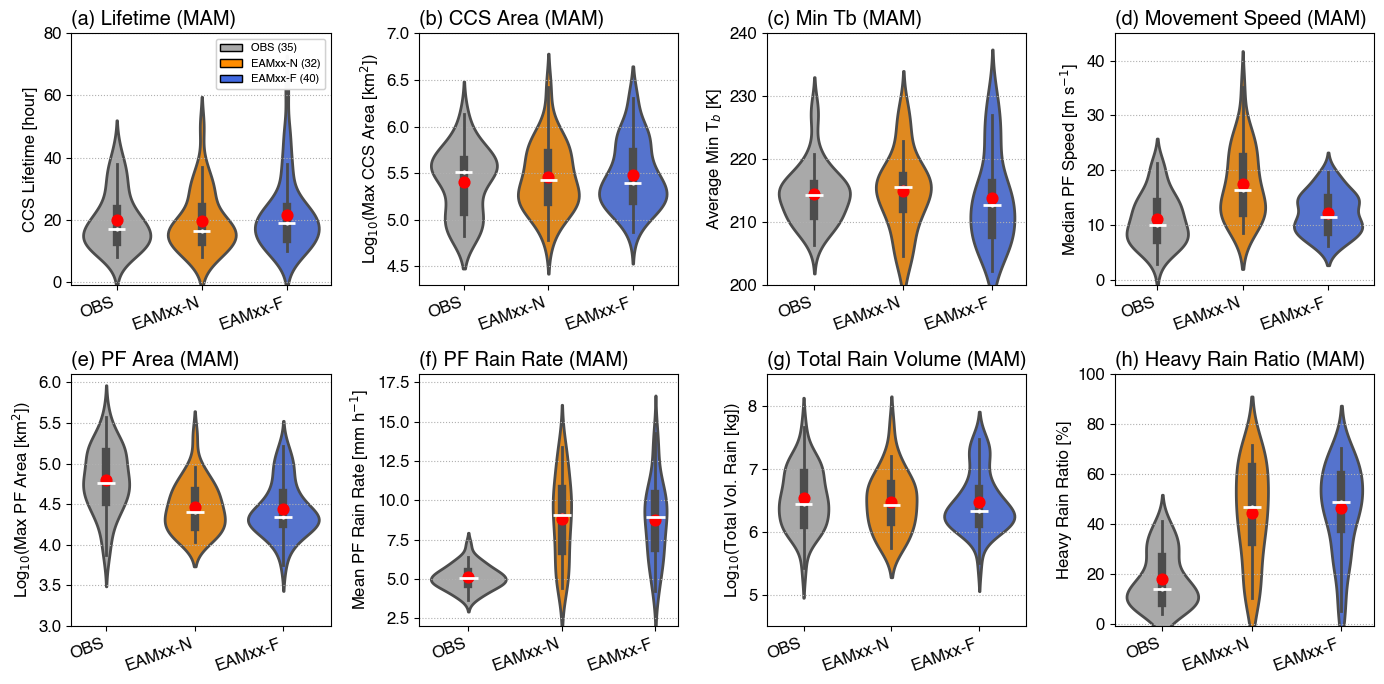

In [67]:
season = 'MAM'
data_arr = [
    [[ccslifetime_nms_l_obs_MAM.values, ccslifetime_nms_l_m1_MAM.values, ccslifetime_nms_l_m2_MAM.values],
     [log10maxccsarea_nms_l_obs_MAM.values, log10maxccsarea_nms_l_m1_MAM.values, log10maxccsarea_nms_l_m2_MAM.values],
     [avgmintb_nms_l_obs_MAM.values, avgmintb_nms_l_m1_MAM.values, avgmintb_nms_l_m2_MAM.values],
     [pfspeed_nms_l_obs_MAM.values, pfspeed_nms_l_m1_MAM.values, pfspeed_nms_l_m2_MAM.values],
    ],
    [[log10maxpfarea_l_nms_obs_MAM.values, log10maxpfarea_l_nms_m1_MAM.values, log10maxpfarea_l_nms_m2_MAM.values],
     [meanpfrainrate_nms_l_obs_MAM.values, meanpfrainrate_nms_l_m1_MAM.values, meanpfrainrate_nms_l_m2_MAM.values],
     [log10pfvolrain_nms_l_obs_MAM.values, log10pfvolrain_nms_l_m1_MAM.values, log10pfvolrain_nms_l_m2_MAM.values],
     [pfhrr_nms_l_obs_MAM.values, pfhrr_nms_l_m1_MAM.values, pfhrr_nms_l_m2_MAM.values],
    ],
]
sigtest = None
# sigtest = [
#     [{'d2':'vs. 500m: '+narrow_sig_lifetime23+'\n'+'vs. 100m: '+narrow_sig_lifetime23, 'd3':'vs. 100m: '+narrow_sig_lifetime34},
#      {'d2':'vs. 500m: '+wide_sig_lifetime23+'\n'+'vs. 100m: '+wide_sig_lifetime23, 'd3':'vs. 100m: '+wide_sig_lifetime34},],
#     [{'d2':'vs. 500m: '+narrow_sig_maxdbz23+'\n'+'vs. 100m: '+narrow_sig_maxdbz23, 'd3':'vs. 100m: '+narrow_sig_maxdbz34},
#      {'d2':'vs. 500m: '+wide_sig_maxdbz23+'\n'+'vs. 100m: '+wide_sig_maxdbz23, 'd3':'vs. 100m: '+wide_sig_maxdbz34},],
#     [{'d2':'vs. 500m: '+narrow_sig_maxETH10dbz23+'\n'+'vs. 100m: '+narrow_sig_maxETH10dbz23, 'd3':'vs. 100m: '+narrow_sig_maxETH10dbz34},
#      {'d2':'vs. 500m: '+wide_sig_maxETH10dbz23+'\n'+'vs. 100m: '+wide_sig_maxETH10dbz23, 'd3':'vs. 100m: '+wide_sig_maxETH10dbz34},],
# ]
ypos_sig = [[180]*2, [10]*2, [18]*2]
titles = [
    [f'(a) Lifetime ({season})', f'(b) CCS Area ({season})', f'(c) Min Tb ({season})', f'(d) Movement Speed ({season})'], 
    [f'(e) PF Area ({season})', f'(f) PF Rain Rate ({season})', f'(g) Total Rain Volume ({season})', f'(h) Heavy Rain Ratio ({season})'],
]
ylabels = [
    ['CCS Lifetime [hour]', 'Log$_{10}$(Max CCS Area [km$^2$])', 'Average Min T$_b$ [K]', 'Median PF Speed [m s$^{-1}$]', ],
    ['Log$_{10}$(Max PF Area [km$^2$])', 'Mean PF Rain Rate [mm h$^{-1}$]', 'Log$_{10}$(Total Vol. Rain [kg])', 'Heavy Rain Ratio [%]'],
]
ylims = [[(-1,80),(4.3,7.0),(200,240),(-1,45)],[(3.0,6.1),(2.0,18),(4.5,8.5),(-1,100)]]
# ylims = None
xlabels = None
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
fontsize = 12
leg_fontsize = 8
leg_rowcol = (0,0)
figsize = (14, 7)
xrotation = 20
figname = f'{figdir}Violin_mcs_2x4_{season}.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname,
                      xrotation=xrotation, name_map=name_map2, leg_rowcol=leg_rowcol, leg_fontsize=leg_fontsize)

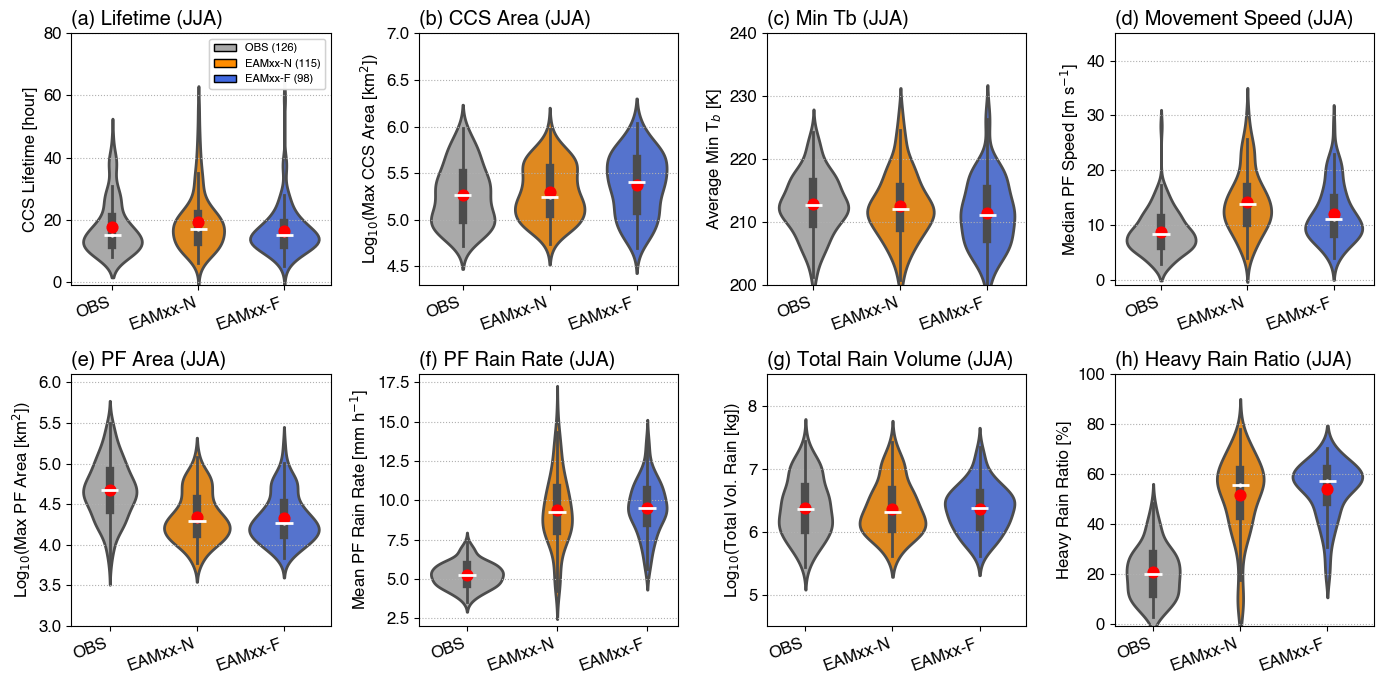

In [68]:
season = 'JJA'
data_arr = [
    [[ccslifetime_nms_l_obs_JJA.values, ccslifetime_nms_l_m1_JJA.values, ccslifetime_nms_l_m2_JJA.values],
     [log10maxccsarea_nms_l_obs_JJA.values, log10maxccsarea_nms_l_m1_JJA.values, log10maxccsarea_nms_l_m2_JJA.values],
     [avgmintb_nms_l_obs_JJA.values, avgmintb_nms_l_m1_JJA.values, avgmintb_nms_l_m2_JJA.values],
     [pfspeed_nms_l_obs_JJA.values, pfspeed_nms_l_m1_JJA.values, pfspeed_nms_l_m2_JJA.values],
    ],
    [[log10maxpfarea_l_nms_obs_JJA.values, log10maxpfarea_l_nms_m1_JJA.values, log10maxpfarea_l_nms_m2_JJA.values],
     [meanpfrainrate_nms_l_obs_JJA.values, meanpfrainrate_nms_l_m1_JJA.values, meanpfrainrate_nms_l_m2_JJA.values],
     [log10pfvolrain_nms_l_obs_JJA.values, log10pfvolrain_nms_l_m1_JJA.values, log10pfvolrain_nms_l_m2_JJA.values],
     [pfhrr_nms_l_obs_JJA.values, pfhrr_nms_l_m1_JJA.values, pfhrr_nms_l_m2_JJA.values],
    ],
]
sigtest = None
ypos_sig = [[180]*2, [10]*2, [18]*2]
titles = [
    [f'(a) Lifetime ({season})', f'(b) CCS Area ({season})', f'(c) Min Tb ({season})', f'(d) Movement Speed ({season})'], 
    [f'(e) PF Area ({season})', f'(f) PF Rain Rate ({season})', f'(g) Total Rain Volume ({season})', f'(h) Heavy Rain Ratio ({season})'],
]
ylabels = [
    ['CCS Lifetime [hour]', 'Log$_{10}$(Max CCS Area [km$^2$])', 'Average Min T$_b$ [K]', 'Median PF Speed [m s$^{-1}$]', ],
    ['Log$_{10}$(Max PF Area [km$^2$])', 'Mean PF Rain Rate [mm h$^{-1}$]', 'Log$_{10}$(Total Vol. Rain [kg])', 'Heavy Rain Ratio [%]'],
]
ylims = [[(-1,80),(4.3,7.0),(200,240),(-1,45)],[(3.0,6.1),(2.0,18),(4.5,8.5),(-1,100)]]
# ylims = None
xlabels = None
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
fontsize = 12
leg_fontsize = 8
leg_rowcol = (0,0)
figsize = (14, 7)
xrotation = 20
figname = f'{figdir}Violin_mcs_2x4_{season}.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname,
                      xrotation=xrotation, name_map=name_map2, leg_rowcol=leg_rowcol, leg_fontsize=leg_fontsize)

In [69]:
figname

'/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/Violin_mcs_2x4_JJA.png'

## Put variables into dictionary for plotting

In [70]:
# # MAM variables
# ccslifetime_dict_MAM = {
#     'obs': kde_ccslifetime_nms_l_obs_MAM,
#     'm1': kde_ccslifetime_nms_l_m1_MAM,
# }
# pfspeed_dict_MAM = {
#     'obs': kde_pfspeed_nms_l_obs_MAM,
#     'm1': kde_pfspeed_nms_l_m1_MAM,
# }
# ccsarea_dict_MAM = {
#     'obs': kde_maxccsarea_nms_l_obs_MAM,
#     'm1': kde_maxccsarea_nms_l_m1_MAM,
# }
# mintb_dict_MAM = {
#     'obs': kde_avgmintb_nms_l_obs_MAM,
#     'm1': kde_avgmintb_nms_l_m1_MAM,
# }
# pfarea_dict_MAM = {
#     'obs': kde_maxpfarea_nms_l_obs_MAM,
#     'm1': kde_maxpfarea_nms_l_m1_MAM,
# }
# pfrainrate_dict_MAM = {
#     'obs': kde_meanpfrainrate_nms_l_obs_MAM,
#     'm1': kde_meanpfrainrate_nms_l_m1_MAM,
# }
# volrain_dict_MAM = {
#     'obs': kde_pfvolrain_nms_l_obs_MAM,
#     'm1': kde_pfvolrain_nms_l_m1_MAM,
# }
# heavyvolrain_dict_MAM = {
#     'obs': kde_pfheavyvolrain_nms_l_obs_MAM,
#     'm1': kde_pfheavyvolrain_nms_l_m1_MAM,
# }
# hrr_dict_MAM = {
#     'obs': kde_pfhrr_nms_l_obs_MAM,
#     'm1': kde_pfhrr_nms_l_m1_MAM,
# }

# # JJA variables
# ccslifetime_dict_JJA = {
#    'obs':kde_ccslifetime_nms_l_obs_JJA,
#    'm1': kde_ccslifetime_nms_l_m1_JJA,
# }
# pfspeed_dict_JJA = {
#    'obs': kde_pfspeed_nms_l_obs_JJA,
#    'm1': kde_pfspeed_nms_l_m1_JJA,
# }
# ccsarea_dict_JJA = {
#    'obs': kde_maxccsarea_nms_l_obs_JJA,
#    'm1': kde_maxccsarea_nms_l_m1_JJA,
# }
# mintb_dict_JJA = {
#    'obs': kde_avgmintb_nms_l_obs_JJA,
#    'm1': kde_avgmintb_nms_l_m1_JJA,
# }
# pfarea_dict_JJA = {
#    'obs': kde_maxpfarea_nms_l_obs_JJA,
#    'm1': kde_maxpfarea_nms_l_m1_JJA,
# }
# pfrainrate_dict_JJA = {
#    'obs': kde_meanpfrainrate_nms_l_obs_JJA,
#    'm1': kde_meanpfrainrate_nms_l_m1_JJA,
# }
# volrain_dict_JJA = {
#    'obs': kde_pfvolrain_nms_l_obs_JJA,
#    'm1': kde_pfvolrain_nms_l_m1_JJA,
# }
# heavyvolrain_dict_JJA = {
#    'obs': kde_pfheavyvolrain_nms_l_obs_JJA,
#    'm1': kde_pfheavyvolrain_nms_l_m1_JJA,
# }
# hrr_dict_JJA = {
#    'obs': kde_pfhrr_nms_l_obs_JJA,
#    'm1': kde_pfhrr_nms_l_m1_JJA,
# }

## Function to plot mirror 1D KDE on (m row x n column) panels

In [71]:
def plot_pdf_mirror_mxn(nrow, ncol, nrowsub, ncolsub, bins, data_top, data_bot, titles, xlabels, ylabels, legends, figname,  
                fontsize=None, map_extent=None, lonbox=None, latbox=None, inset_param=None, map_panel=None,
                xscale=None, yscale=None, xlims=None, ylims=None, label_topbot=None, label_pos=None,
                legend_fontsize=11, legend_loc=None, legend_ncol=None, figsize=None):
    
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['font.weight'] = 'regular'
    
    lw = 3
    lcolors = {
        'obs':'steelblue', 
        'm1': 'darkorange',
    }
    
    fig = plt.figure(figsize=figsize, constrained_layout=False, dpi=100)
    outer_grid = fig.add_gridspec(nrow, ncol, wspace=0.25, hspace=0.3)

    for row in range(nrow):
        for col in range(ncol):
            # gridspec inside gridspec
            inner_grid = outer_grid[row, col].subgridspec(nrowsub, ncolsub, wspace=0, hspace=0)
            axs = inner_grid.subplots()
            ax1 = axs[0]  # top
            ax2 = axs[1]  # bottom
            ax2.invert_yaxis()
            # Top panel
            ax1.plot(bins[row][col], data_top[row][col]['obs'], lcolors['obs'], lw=lw, label=legends['obs'])
            ax1.plot(bins[row][col], data_top[row][col]['m1'], lcolors['m1'], lw=lw, label=legends['m1'])
            # Bottom panel
            ax2.plot(bins[row][col], data_bot[row][col]['obs'], lcolors['obs'], lw=lw, label=legends['obs'])
            ax2.plot(bins[row][col], data_bot[row][col]['m1'], lcolors['m1'], lw=lw, label=legends['m1'])
            # Labels, gridlines, etc.
            ax1.grid(which='major', ls='--')
            ax2.grid(which='major', ls='--')
            ax1.set_title(titles[row][col], loc='left')
            ax2.set_xlabel(xlabels[row][col])
            # Hide x axis label marks
            ax1.tick_params(labelbottom=False) 
            # Label top/bottom panels
            ax1.text(label_pos['top']['x'], label_pos['top']['y'], label_topbot['top'], ha='left', transform=ax1.transAxes)
            ax2.text(label_pos['bottom']['x'], label_pos['bottom']['y'], label_topbot['bottom'], ha='left', transform=ax2.transAxes)
            # Label yaxis, legend
            if (col == 0):
                ax1.legend(fontsize=legend_fontsize, loc=legend_loc[0], ncol=legend_ncol[0])
                ax1.text(-0.25, 1, ylabels[row][col], va='center', ha='center', rotation=90, transform=ax2.transAxes)           
            
            # Plot inset map
            if (row == map_panel['row']) & (col == map_panel['col']) & (map_panel['rowsub'] == 0) & (map_panel['colsub'] == 0):
                resolution = '110m'
                land = cfeature.NaturalEarthFeature('physical', 'land', resolution)
                ocean = cfeature.NaturalEarthFeature('physical', 'ocean', resolution)
                states = cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces_lakes', resolution)
                # proj = ccrs.PlateCarree(central_longitude=180)
                proj = ccrs.PlateCarree(central_longitude=0)
                box_proj = ccrs.PlateCarree(central_longitude=0)
                sub_ax = inset_axes(ax1, width=inset_param['width'], height=inset_param['height'], loc=inset_param['loc'],
                                    axes_class=cartopy.mpl.geoaxes.GeoAxes, borderpad=inset_param['borderpad'], 
                                    axes_kwargs=dict(projection=proj))
                sub_ax.set_extent(map_extent, box_proj)
                # Add land, coastlines, borders to inset
                sub_ax.add_feature(land, facecolor='gainsboro', edgecolor='k')
                sub_ax.add_feature(ocean, edgecolor='none', facecolor=cfeature.COLORS['water'])
                sub_ax.add_feature(land, facecolor='none', edgecolor='k', zorder=4)
                sub_ax.add_feature(states, edgecolor='k', facecolor='none', zorder=4)
                # Define the vertices of the rectangle in the projection coordinates
                x1, y1 = proj.transform_point(lon_bounds[0], lat_bounds[0], proj)
                x2, y2 = proj.transform_point(lon_bounds[1], lat_bounds[1], proj)
                # Plot rectangle
                sub_ax.add_patch(mpl.patches.Rectangle((x1, y1), x2-x1, y2-y1, transform=proj, fill=None, lw=2, edgecolor='g', zorder=10))
                sub_ax.add_patch(mpl.patches.Rectangle((x1, y1), x2-x1, y2-y1, transform=proj, fill='g', edgecolor=None, alpha=0.6, zorder=10))

    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

## Setup legend, inset map

In [72]:
legends = {
    'obs': 'OBS',
    'm1': 'WRF',
}
# Inset map settings
map_extent = [lon_bounds[0]-5,lon_bounds[1]+5,lat_bounds[0]-3,lat_bounds[1]+3]
lonbox = [lon_bounds[0], lon_bounds[1]-1]
latbox = [lat_bounds[0], lat_bounds[1]]
inset_param = {'width':'40%', 'height':'40%', 'loc':'upper right', 'borderpad':0.1}
map_extent, lonbox, latbox

([-113, -80, 27, 53], [-108, -86], [30, 50])

In [73]:
# bins = [
#     [lifetime_bins, ccsarea_bins, avgmintb_bins, pfspeed_bins],
#     [pfarea_bins, pfrainrate_bins, volrain_bins, pfhrr_bins],    
# ]
# data_top = [
#     [ccslifetime_dict_MAM, ccsarea_dict_MAM, mintb_dict_MAM, pfspeed_dict_MAM], 
#     [pfarea_dict_MAM, pfrainrate_dict_MAM, volrain_dict_MAM, hrr_dict_MAM, ],
# ]
# data_bot = [
#     [ccslifetime_dict_JJA, ccsarea_dict_JJA, mintb_dict_JJA, pfspeed_dict_JJA], 
#     [pfarea_dict_JJA, pfrainrate_dict_JJA, volrain_dict_JJA, hrr_dict_JJA, ],
# ]
# titles = [
#     ['(a) MCS Lifetime', '(b) CCS Area', '(c) Min Tb', '(d) Movement Speed'],
#     ['(e) PF Area', '(f) PF Rain Rate', '(g) Total Rain Volume', '(h) Heavy Rain Volume Ratio'],
# ]
# xlabels = [
#     ['CCS Lifetime [hour]', 'Log$_{10}$(Max CCS Area [km$^2$])', 'Average Min T$_b$ [K]', 'Median PF Speed [m s$^{-1}$]', ],
#     ['Log$_{10}$(Max PF Area [km$^2$])', 'Mean PF Rain Rate [mm h$^{-1}$]', 'Log$_{10}$(Total Vol. Rain [kg])', 'Heavy Rain Ratio [%]'],
# ]
# ylabels = [['Frequency','','',''], ['Frequency','','','']]
# label_topbot = {'top':'MAM', 'bottom':'JJA'}
# label_pos = {'top':{'x':0.02, 'y':0.9}, 'bottom':{'x':0.02, 'y':0.1}}
# legend_loc = ['upper right', 'upper right']
# legend_ncol = [1, 1]
# map_panel = {'row': 0, 'col': 3, 'rowsub': 0, 'colsub': 0}
# figname = f'{figdir}kde1d_mcs_MAM_JJA_2x4_{region}.png'
# fig = plot_pdf_mirror_mxn(2, 4, 2, 1, bins, data_top, data_bot, titles, xlabels, ylabels, legends, figname,
#                           fontsize=12, map_extent=map_extent, lonbox=lonbox, latbox=latbox, inset_param=inset_param, map_panel=map_panel,
#                           legend_fontsize=10, legend_loc=legend_loc, legend_ncol=legend_ncol, label_topbot=label_topbot, label_pos=label_pos, 
#                           figsize=[16,8])

## Function to plot 1D KDE on (m x n) panels

In [74]:
# def plot_pdf_mxn(nrow, ncol, bins, data_arr, titles, xlabels, ylabels, legends, figname,  
#                 map_extent=None, lonbox=None, latbox=None, inset_param=None, map_panel=[0,0],
#                 fontsize=12, legend_fontsize=11, legend_loc='best', figsize=None):
    
#     mpl.rcParams['font.size'] = fontsize
#     mpl.rcParams['font.family'] = 'Helvetica'
#     mpl.rcParams['font.weight'] = 'regular'
#     fig = plt.figure(figsize=figsize, constrained_layout=False, dpi=100)
#     outer_grid = fig.add_gridspec(nrow, ncol, wspace=0.25, hspace=0.35)

#     lw = 3
#     lcolors = {
#         'obs':'steelblue', 
#         'm1': 'darkorange',
#     }

#     for row in range(0, nrow):
#         for col in range(0, ncol): 
#             ax = plt.subplot(outer_grid[row,col])
#             ax.plot(bins[row][col], data_arr[row][col]['obs'], lcolors['obs'], lw=lw, label=legends['obs'])
#             ax.plot(bins[row][col], data_arr[row][col]['m1'], lcolors['m1'], lw=lw, label=legends['m1'])
#             # Labels
#             if (col == 0): 
#                 ax.legend(fontsize=legend_fontsize, loc=legend_loc)
#             ax.grid(which='major', ls='--')
#             ax.set_title(titles[row][col], loc='left')
#             ax.set_xlabel(xlabels[row][col])
#             # if (col == 0):
#             ax.set_ylabel(ylabels[row][col])
#             # ax.set_xticks(xticks[col])
#             # ax.set_xlim(xlims[col][0], xlims[col][1])
#             # ax.set_ylim(ylims[row][0], ylims[row][1])
            
#             # Plot inset map
#             if (row == map_panel[0]) & (col == map_panel[1]):
#                 resolution = '110m'
#                 land = cfeature.NaturalEarthFeature('physical', 'land', resolution)
#                 ocean = cfeature.NaturalEarthFeature('physical', 'ocean', resolution)
#                 states = cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces_lakes', resolution)
#                 # proj = ccrs.PlateCarree(central_longitude=180)
#                 proj = ccrs.PlateCarree(central_longitude=0)
#                 box_proj = ccrs.PlateCarree(central_longitude=0)
#                 sub_ax = inset_axes(ax, width=inset_param['width'], height=inset_param['height'], loc=inset_param['loc'],
#                                     axes_class=cartopy.mpl.geoaxes.GeoAxes, borderpad=inset_param['borderpad'], 
#                                     axes_kwargs=dict(projection=proj))
#                 sub_ax.set_extent(map_extent, box_proj)
#                 # Add land, coastlines, borders to inset
#                 sub_ax.add_feature(land, facecolor='gainsboro', edgecolor='k')
#                 sub_ax.add_feature(ocean, edgecolor='none', facecolor=cfeature.COLORS['water'])
#                 sub_ax.add_feature(land, facecolor='none', edgecolor='k', zorder=4)
#                 sub_ax.add_feature(states, edgecolor='k', facecolor='none', zorder=4)
#                 # Define the vertices of the rectangle in the projection coordinates
#                 x1, y1 = proj.transform_point(lon_bounds[0], lat_bounds[0], proj)
#                 x2, y2 = proj.transform_point(lon_bounds[1], lat_bounds[1], proj)
#                 # Plot rectangle
#                 sub_ax.add_patch(mpl.patches.Rectangle((x1, y1), x2-x1, y2-y1, transform=proj, fill=None, lw=2, edgecolor='g', zorder=10))
#                 sub_ax.add_patch(mpl.patches.Rectangle((x1, y1), x2-x1, y2-y1, transform=proj, fill='g', edgecolor=None, alpha=0.6, zorder=10))

#     fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
#     return fig

In [75]:
# bins = [
#     [lifetime_bins, ccsarea_bins, avgmintb_bins, pfspeed_bins],
#     [pfarea_bins, pfrainrate_bins, volrain_bins, pfhrr_bins],    
# ]
# data_arr = [
#     [ccslifetime_dict_JJA, ccsarea_dict_JJA, mintb_dict_JJA, pfspeed_dict_JJA], 
#     [pfarea_dict_JJA, pfrainrate_dict_JJA, volrain_dict_JJA, hrr_dict_JJA, ],
# ]
# titles = [
#     ['(a) MCS Lifetime (JJA)', '(b) CCS Area (JJA)', '(c) Min Tb (JJA)', '(d) Median PF Speed (JJA)'],
#     ['(e) PF Area (JJA)', '(f) PF Rain Rate (JJA)', '(g) Total Rain Vol. (JJA)', '(h) Heavy Rain Ratio (JJA)'],
# ]
# xlabels = [
#     ['CCS Lifetime [hour]', 'Log$_{10}$(Max CCS Area [km$^2$])', 'Average Min T$_b$ [K]', 'PF Speed [m s$^{-1}$]'],
#     ['Log$_{10}$(Max PF Area [km$^2$])', 'Mean PF Rain Rate [mm h$^{-1}$]', 'Log$_{10}$(Total Vol. Rain [kg])', 'Heavy Rain Ratio [%]'],
# ]
# ylabels = [['Frequency','','',''], ['Frequency','','','']]
# figname = f'{figdir}kde1d_mcs_JJA_2x4_{region}.png'
# fig = plot_pdf_mxn(2, 4, bins, data_arr, titles, xlabels, ylabels, legends, figname,
#                    map_extent=map_extent, lonbox=lonbox, latbox=latbox, inset_param=inset_param, map_panel=[0,3],
#                    legend_fontsize=10, legend_loc='best', figsize=[16,8])

In [76]:
# bins = [
#     [lifetime_bins, ccsarea_bins, avgmintb_bins, pfspeed_bins],
#     [pfarea_bins, pfrainrate_bins, volrain_bins, pfhrr_bins],    
# ]
# data_arr = [
#     [ccslifetime_dict_MAM, ccsarea_dict_MAM, mintb_dict_MAM, pfspeed_dict_MAM], 
#     [pfarea_dict_MAM, pfrainrate_dict_MAM, volrain_dict_MAM, hrr_dict_MAM, ],
# ]
# titles = [
#     ['(a) MCS Lifetime (MAM)', '(b) CCS Area (MAM)', '(c) Min Tb (MAM)', '(d) Median PF Speed (MAM)'],
#     ['(e) PF Area (MAM)', '(f) PF Rain Rate (MAM)', '(g) Total Rain Vol. (MAM)', '(h) Heavy Rain Ratio (MAM)'],
# ]
# xlabels = [
#     ['CCS Lifetime [hour]', 'Log$_{10}$(Max CCS Area [km$^2$])', 'Average Min T$_b$ [K]', 'PF Speed [m s$^{-1}$]'],
#     ['Log$_{10}$(Max PF Area [km$^2$])', 'Mean PF Rain Rate [mm h$^{-1}$]', 'Log$_{10}$(Total Vol. Rain [kg])', 'Heavy Rain Ratio [%]'],
# ]
# ylabels = [['Frequency','','',''], ['Frequency','','','']]
# figname = f'{figdir}kde1d_mcs_MAM_2x4_{region}.png'
# fig = plot_pdf_mxn(2, 4, bins, data_arr, titles, xlabels, ylabels, legends, figname,
#                    map_extent=map_extent, lonbox=lonbox, latbox=latbox, inset_param=inset_param, map_panel=[0,3],
#                    legend_fontsize=10, legend_loc='best', figsize=[16,8])

In [77]:
figdir

'/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/'

## Function to composite track time-evolution by 1 condition

In [78]:
import warnings
def get_comp_tracks_by1cond(in_var, x_cond_var, x_cond_range, quantiles):
    # Suppress RuntimeWarning
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        # Filter by one condition
        in_var_cond = in_var.where((x_cond_var >= x_cond_range[0]) & (x_cond_var <= x_cond_range[1]), drop=True)
        nsamples = in_var_cond.sizes['tracks']
        out_var_mean = in_var_cond.mean(dim='tracks')
        out_var_qntl = in_var_cond.quantile(quantiles, dim='tracks')
    return out_var_mean, out_var_qntl, nsamples

## Composite MCS time-evolution by CCS lifetime (for non-merge-split tracks only)
- Note the use of Dataset (ds_nms)

In [79]:
# Set lifetime range for composites
lifetime_range1 = [10, 15]
lifetime_range2 = [18, 26]
quantiles = [0.25, 0.5, 0.75]

# Add mergers/splits to get total CCS area
ccsarea_l_obs = (ds_nms_l_obs.ccs_area + ds_nms_l_obs.merge_ccs_area.sum(dim='mergers') + ds_nms_l_obs.split_ccs_area.sum(dim='mergers')).compute()
ccsarea_l_m1 = (ds_nms_l_m1.ccs_area + ds_nms_l_m1.merge_ccs_area.sum(dim='mergers') + ds_nms_l_m1.split_ccs_area.sum(dim='mergers')).compute()
ccsarea_l_m2 = (ds_nms_l_m2.ccs_area + ds_nms_l_m2.merge_ccs_area.sum(dim='mergers') + ds_nms_l_m2.split_ccs_area.sum(dim='mergers')).compute()

# CCS lifetime
ccslifetime_l_obs = (ds_nms_l_obs.track_duration * time_res_obs).compute()
ccslifetime_l_m1 = (ds_nms_l_m1.track_duration * time_res_m1).compute()
ccslifetime_l_m2 = (ds_nms_l_m2.track_duration * time_res_m2).compute()

# By season
ccslifetime_l_obs_MAM = ccslifetime_l_obs.where(start_season_obs == 'MAM', drop=True)
ccslifetime_l_obs_JJA = ccslifetime_l_obs.where(start_season_obs == 'JJA', drop=True)
ccslifetime_l_m1_MAM = ccslifetime_l_m1.where(start_season_m1 == 'MAM', drop=True)
ccslifetime_l_m1_JJA = ccslifetime_l_m1.where(start_season_m1 == 'JJA', drop=True)
ccslifetime_l_m2_MAM = ccslifetime_l_m2.where(start_season_m2 == 'MAM', drop=True)
ccslifetime_l_m2_JJA = ccslifetime_l_m2.where(start_season_m2 == 'JJA', drop=True)

ccsarea_l_obs_MAM = ccsarea_l_obs.where(start_season_obs == 'MAM', drop=True)
ccsarea_l_obs_JJA = ccsarea_l_obs.where(start_season_obs == 'JJA', drop=True)
ccsarea_l_m1_MAM = ccsarea_l_m1.where(start_season_m1 == 'MAM', drop=True)
ccsarea_l_m1_JJA = ccsarea_l_m1.where(start_season_m1 == 'JJA', drop=True)
ccsarea_l_m2_MAM = ccsarea_l_m2.where(start_season_m2 == 'MAM', drop=True)
ccsarea_l_m2_JJA = ccsarea_l_m2.where(start_season_m2 == 'JJA', drop=True)

# CCS Area
avg1_ccsarea_l_obs_MAM, qntl1_ccsarea_l_obs_MAM, ns1_l_obs_MAM = get_comp_tracks_by1cond(ccsarea_l_obs_MAM, ccslifetime_l_obs_MAM, lifetime_range1, quantiles)
avg2_ccsarea_l_obs_MAM, qntl2_ccsarea_l_obs_MAM, ns2_l_obs_MAM = get_comp_tracks_by1cond(ccsarea_l_obs_MAM, ccslifetime_l_obs_MAM, lifetime_range2, quantiles)
avg1_ccsarea_l_obs_JJA, qntl1_ccsarea_l_obs_JJA, ns1_l_obs_JJA = get_comp_tracks_by1cond(ccsarea_l_obs_JJA, ccslifetime_l_obs_JJA, lifetime_range1, quantiles)
avg2_ccsarea_l_obs_JJA, qntl2_ccsarea_l_obs_JJA, ns2_l_obs_JJA = get_comp_tracks_by1cond(ccsarea_l_obs_JJA, ccslifetime_l_obs_JJA, lifetime_range2, quantiles)

avg1_ccsarea_l_m1_MAM, qntl1_ccsarea_l_m1_MAM, ns1_l_m1_MAM = get_comp_tracks_by1cond(ccsarea_l_m1_MAM, ccslifetime_l_m1_MAM, lifetime_range1, quantiles)
avg2_ccsarea_l_m1_MAM, qntl2_ccsarea_l_m1_MAM, ns2_l_m1_MAM = get_comp_tracks_by1cond(ccsarea_l_m1_MAM, ccslifetime_l_m1_MAM, lifetime_range2, quantiles)
avg1_ccsarea_l_m1_JJA, qntl1_ccsarea_l_m1_JJA, ns1_l_m1_JJA = get_comp_tracks_by1cond(ccsarea_l_m1_JJA, ccslifetime_l_m1_JJA, lifetime_range1, quantiles)
avg2_ccsarea_l_m1_JJA, qntl2_ccsarea_l_m1_JJA, ns2_l_m1_JJA = get_comp_tracks_by1cond(ccsarea_l_m1_JJA, ccslifetime_l_m1_JJA, lifetime_range2, quantiles)

avg1_ccsarea_l_m2_MAM, qntl1_ccsarea_l_m2_MAM, ns1_l_m2_MAM = get_comp_tracks_by1cond(ccsarea_l_m2_MAM, ccslifetime_l_m2_MAM, lifetime_range1, quantiles)
avg2_ccsarea_l_m2_MAM, qntl2_ccsarea_l_m2_MAM, ns2_l_m2_MAM = get_comp_tracks_by1cond(ccsarea_l_m2_MAM, ccslifetime_l_m2_MAM, lifetime_range2, quantiles)
avg1_ccsarea_l_m2_JJA, qntl1_ccsarea_l_m2_JJA, ns1_l_m2_JJA = get_comp_tracks_by1cond(ccsarea_l_m2_JJA, ccslifetime_l_m2_JJA, lifetime_range1, quantiles)
avg2_ccsarea_l_m2_JJA, qntl2_ccsarea_l_m2_JJA, ns2_l_m2_JJA = get_comp_tracks_by1cond(ccsarea_l_m2_JJA, ccslifetime_l_m2_JJA, lifetime_range2, quantiles)

print(f'Sample number (range1) MAM: {ns1_l_obs_MAM} (OBS), {ns1_l_m1_MAM} (m1), {ns1_l_m2_MAM} (m2)')
print(f'Sample number (range2) MAM: {ns2_l_obs_MAM} (OBS), {ns2_l_m1_MAM} (m1), {ns2_l_m2_MAM} (m2)')
print(f'Sample number (range1) JJA: {ns1_l_obs_JJA} (OBS), {ns1_l_m1_JJA} (m1), {ns1_l_m2_JJA} (m2)')
print(f'Sample number (range2) JJA: {ns2_l_obs_JJA} (OBS), {ns2_l_m1_JJA} (m1), {ns2_l_m2_JJA} (m2)')

Sample number (range1) MAM: 12 (OBS), 11 (m1), 13 (m2)
Sample number (range2) MAM: 9 (OBS), 7 (m1), 17 (m2)
Sample number (range1) JJA: 55 (OBS), 35 (m1), 49 (m2)
Sample number (range2) JJA: 23 (OBS), 40 (m1), 23 (m2)


In [80]:
# Min Tb
ccs_mintb_l_obs_MAM = ds_nms_l_obs.corecold_mintb.where(start_season_obs == 'MAM', drop=True).compute()
ccs_mintb_l_obs_JJA = ds_nms_l_obs.corecold_mintb.where(start_season_obs == 'JJA', drop=True).compute()
ccs_mintb_l_m1_MAM = ds_nms_l_m1.corecold_mintb.where(start_season_m1 == 'MAM', drop=True).compute()
ccs_mintb_l_m1_JJA = ds_nms_l_m1.corecold_mintb.where(start_season_m1 == 'JJA', drop=True).compute()
ccs_mintb_l_m2_MAM = ds_nms_l_m2.corecold_mintb.where(start_season_m2 == 'MAM', drop=True).compute()
ccs_mintb_l_m2_JJA = ds_nms_l_m2.corecold_mintb.where(start_season_m2 == 'JJA', drop=True).compute()

avg1_mintb_l_obs_MAM, qntl1_mintb_l_obs_MAM, ns1_l_obs_MAM = get_comp_tracks_by1cond(ccs_mintb_l_obs_MAM, ccslifetime_l_obs_MAM, lifetime_range1, quantiles)
avg2_mintb_l_obs_MAM, qntl2_mintb_l_obs_MAM, ns2_l_obs_MAM = get_comp_tracks_by1cond(ccs_mintb_l_obs_MAM, ccslifetime_l_obs_MAM, lifetime_range2, quantiles)
avg1_mintb_l_obs_JJA, qntl1_mintb_l_obs_JJA, ns1_l_obs_JJA = get_comp_tracks_by1cond(ccs_mintb_l_obs_JJA, ccslifetime_l_obs_JJA, lifetime_range1, quantiles)
avg2_mintb_l_obs_JJA, qntl2_mintb_l_obs_JJA, ns2_l_obs_JJA = get_comp_tracks_by1cond(ccs_mintb_l_obs_JJA, ccslifetime_l_obs_JJA, lifetime_range2, quantiles)

avg1_mintb_l_m1_MAM, qntl1_mintb_l_m1_MAM, ns1_l_m1_MAM = get_comp_tracks_by1cond(ccs_mintb_l_m1_MAM, ccslifetime_l_m1_MAM, lifetime_range1, quantiles)
avg2_mintb_l_m1_MAM, qntl2_mintb_l_m1_MAM, ns2_l_m1_MAM = get_comp_tracks_by1cond(ccs_mintb_l_m1_MAM, ccslifetime_l_m1_MAM, lifetime_range2, quantiles)
avg1_mintb_l_m1_JJA, qntl1_mintb_l_m1_JJA, ns1_l_m1_JJA = get_comp_tracks_by1cond(ccs_mintb_l_m1_JJA, ccslifetime_l_m1_JJA, lifetime_range1, quantiles)
avg2_mintb_l_m1_JJA, qntl2_mintb_l_m1_JJA, ns2_l_m1_JJA = get_comp_tracks_by1cond(ccs_mintb_l_m1_JJA, ccslifetime_l_m1_JJA, lifetime_range2, quantiles)

avg1_mintb_l_m2_MAM, qntl1_mintb_l_m2_MAM, ns1_l_m2_MAM = get_comp_tracks_by1cond(ccs_mintb_l_m2_MAM, ccslifetime_l_m2_MAM, lifetime_range1, quantiles)
avg2_mintb_l_m2_MAM, qntl2_mintb_l_m2_MAM, ns2_l_m2_MAM = get_comp_tracks_by1cond(ccs_mintb_l_m2_MAM, ccslifetime_l_m2_MAM, lifetime_range2, quantiles)
avg1_mintb_l_m2_JJA, qntl1_mintb_l_m2_JJA, ns1_l_m2_JJA = get_comp_tracks_by1cond(ccs_mintb_l_m2_JJA, ccslifetime_l_m2_JJA, lifetime_range1, quantiles)
avg2_mintb_l_m2_JJA, qntl2_mintb_l_m2_JJA, ns2_l_m2_JJA = get_comp_tracks_by1cond(ccs_mintb_l_m2_JJA, ccslifetime_l_m2_JJA, lifetime_range2, quantiles)

In [81]:
# Largest PF Area
pf_area_l_obs_MAM = ds_nms_l_obs.pf_area.isel(nmaxpf=0).where(start_season_obs == 'MAM', drop=True).compute()
pf_area_l_obs_JJA = ds_nms_l_obs.pf_area.isel(nmaxpf=0).where(start_season_obs == 'JJA', drop=True).compute()
pf_area_l_m1_MAM = ds_nms_l_m1.pf_area.isel(nmaxpf=0).where(start_season_m1 == 'MAM', drop=True).compute()
pf_area_l_m1_JJA = ds_nms_l_m1.pf_area.isel(nmaxpf=0).where(start_season_m1 == 'JJA', drop=True).compute()
pf_area_l_m2_MAM = ds_nms_l_m2.pf_area.isel(nmaxpf=0).where(start_season_m2 == 'MAM', drop=True).compute()
pf_area_l_m2_JJA = ds_nms_l_m2.pf_area.isel(nmaxpf=0).where(start_season_m2 == 'JJA', drop=True).compute()

avg1_pfarea_l_obs_MAM, qntl1_pfarea_l_obs_MAM, ns1_l_obs_MAM = get_comp_tracks_by1cond(pf_area_l_obs_MAM, ccslifetime_l_obs_MAM, lifetime_range1, quantiles)
avg2_pfarea_l_obs_MAM, qntl2_pfarea_l_obs_MAM, ns2_l_obs_MAM = get_comp_tracks_by1cond(pf_area_l_obs_MAM, ccslifetime_l_obs_MAM, lifetime_range2, quantiles)
avg1_pfarea_l_obs_JJA, qntl1_pfarea_l_obs_JJA, ns1_l_obs_JJA = get_comp_tracks_by1cond(pf_area_l_obs_JJA, ccslifetime_l_obs_JJA, lifetime_range1, quantiles)
avg2_pfarea_l_obs_JJA, qntl2_pfarea_l_obs_JJA, ns2_l_obs_JJA = get_comp_tracks_by1cond(pf_area_l_obs_JJA, ccslifetime_l_obs_JJA, lifetime_range2, quantiles)

avg1_pfarea_l_m1_MAM, qntl1_pfarea_l_m1_MAM, ns1_l_m1_MAM = get_comp_tracks_by1cond(pf_area_l_m1_MAM, ccslifetime_l_m1_MAM, lifetime_range1, quantiles)
avg2_pfarea_l_m1_MAM, qntl2_pfarea_l_m1_MAM, ns2_l_m1_MAM = get_comp_tracks_by1cond(pf_area_l_m1_MAM, ccslifetime_l_m1_MAM, lifetime_range2, quantiles)
avg1_pfarea_l_m1_JJA, qntl1_pfarea_l_m1_JJA, ns1_l_m1_JJA = get_comp_tracks_by1cond(pf_area_l_m1_JJA, ccslifetime_l_m1_JJA, lifetime_range1, quantiles)
avg2_pfarea_l_m1_JJA, qntl2_pfarea_l_m1_JJA, ns2_l_m1_JJA = get_comp_tracks_by1cond(pf_area_l_m1_JJA, ccslifetime_l_m1_JJA, lifetime_range2, quantiles)

avg1_pfarea_l_m2_MAM, qntl1_pfarea_l_m2_MAM, ns1_l_m2_MAM = get_comp_tracks_by1cond(pf_area_l_m2_MAM, ccslifetime_l_m2_MAM, lifetime_range1, quantiles)
avg2_pfarea_l_m2_MAM, qntl2_pfarea_l_m2_MAM, ns2_l_m2_MAM = get_comp_tracks_by1cond(pf_area_l_m2_MAM, ccslifetime_l_m2_MAM, lifetime_range2, quantiles)
avg1_pfarea_l_m2_JJA, qntl1_pfarea_l_m2_JJA, ns1_l_m2_JJA = get_comp_tracks_by1cond(pf_area_l_m2_JJA, ccslifetime_l_m2_JJA, lifetime_range1, quantiles)
avg2_pfarea_l_m2_JJA, qntl2_pfarea_l_m2_JJA, ns2_l_m2_JJA = get_comp_tracks_by1cond(pf_area_l_m2_JJA, ccslifetime_l_m2_JJA, lifetime_range2, quantiles)

In [82]:
# Largest PF Equivalent Diameter
pfdiam_l_obs_MAM = 2*np.sqrt(ds_nms_l_obs.pf_area.isel(nmaxpf=0).where(start_season_obs == 'MAM', drop=True).compute() / np.pi)
pfdiam_l_obs_JJA = 2*np.sqrt(ds_nms_l_obs.pf_area.isel(nmaxpf=0).where(start_season_obs == 'JJA', drop=True).compute() / np.pi)
pfdiam_l_m1_MAM = 2*np.sqrt(ds_nms_l_m1.pf_area.isel(nmaxpf=0).where(start_season_m1 == 'MAM', drop=True).compute() / np.pi)
pfdiam_l_m1_JJA = 2*np.sqrt(ds_nms_l_m1.pf_area.isel(nmaxpf=0).where(start_season_m1 == 'JJA', drop=True).compute() / np.pi)
pfdiam_l_m2_MAM = 2*np.sqrt(ds_nms_l_m2.pf_area.isel(nmaxpf=0).where(start_season_m2 == 'MAM', drop=True).compute() / np.pi)
pfdiam_l_m2_JJA = 2*np.sqrt(ds_nms_l_m2.pf_area.isel(nmaxpf=0).where(start_season_m2 == 'JJA', drop=True).compute() / np.pi)

avg1_pfdiam_l_obs_MAM, qntl1_pfdiam_l_obs_MAM, ns1_l_obs_MAM = get_comp_tracks_by1cond(pfdiam_l_obs_MAM, ccslifetime_l_obs_MAM, lifetime_range1, quantiles)
avg2_pfdiam_l_obs_MAM, qntl2_pfdiam_l_obs_MAM, ns2_l_obs_MAM = get_comp_tracks_by1cond(pfdiam_l_obs_MAM, ccslifetime_l_obs_MAM, lifetime_range2, quantiles)
avg1_pfdiam_l_obs_JJA, qntl1_pfdiam_l_obs_JJA, ns1_l_obs_JJA = get_comp_tracks_by1cond(pfdiam_l_obs_JJA, ccslifetime_l_obs_JJA, lifetime_range1, quantiles)
avg2_pfdiam_l_obs_JJA, qntl2_pfdiam_l_obs_JJA, ns2_l_obs_JJA = get_comp_tracks_by1cond(pfdiam_l_obs_JJA, ccslifetime_l_obs_JJA, lifetime_range2, quantiles)

avg1_pfdiam_l_m1_MAM, qntl1_pfdiam_l_m1_MAM, ns1_l_m1_MAM = get_comp_tracks_by1cond(pfdiam_l_m1_MAM, ccslifetime_l_m1_MAM, lifetime_range1, quantiles)
avg2_pfdiam_l_m1_MAM, qntl2_pfdiam_l_m1_MAM, ns2_l_m1_MAM = get_comp_tracks_by1cond(pfdiam_l_m1_MAM, ccslifetime_l_m1_MAM, lifetime_range2, quantiles)
avg1_pfdiam_l_m1_JJA, qntl1_pfdiam_l_m1_JJA, ns1_l_m1_JJA = get_comp_tracks_by1cond(pfdiam_l_m1_JJA, ccslifetime_l_m1_JJA, lifetime_range1, quantiles)
avg2_pfdiam_l_m1_JJA, qntl2_pfdiam_l_m1_JJA, ns2_l_m1_JJA = get_comp_tracks_by1cond(pfdiam_l_m1_JJA, ccslifetime_l_m1_JJA, lifetime_range2, quantiles)

avg1_pfdiam_l_m2_MAM, qntl1_pfdiam_l_m2_MAM, ns1_l_m2_MAM = get_comp_tracks_by1cond(pfdiam_l_m2_MAM, ccslifetime_l_m2_MAM, lifetime_range1, quantiles)
avg2_pfdiam_l_m2_MAM, qntl2_pfdiam_l_m2_MAM, ns2_l_m2_MAM = get_comp_tracks_by1cond(pfdiam_l_m2_MAM, ccslifetime_l_m2_MAM, lifetime_range2, quantiles)
avg1_pfdiam_l_m2_JJA, qntl1_pfdiam_l_m2_JJA, ns1_l_m2_JJA = get_comp_tracks_by1cond(pfdiam_l_m2_JJA, ccslifetime_l_m2_JJA, lifetime_range1, quantiles)
avg2_pfdiam_l_m2_JJA, qntl2_pfdiam_l_m2_JJA, ns2_l_m2_JJA = get_comp_tracks_by1cond(pfdiam_l_m2_JJA, ccslifetime_l_m2_JJA, lifetime_range2, quantiles)

In [83]:
# Largest PF Rain Rate
pfrainrate_l_obs_MAM = ds_nms_l_obs.pf_rainrate.isel(nmaxpf=0).where(start_season_obs == 'MAM', drop=True).compute()
pfrainrate_l_obs_JJA = ds_nms_l_obs.pf_rainrate.isel(nmaxpf=0).where(start_season_obs == 'JJA', drop=True).compute()
pfrainrate_l_m1_MAM = ds_nms_l_m1.pf_rainrate.isel(nmaxpf=0).where(start_season_m1 == 'MAM', drop=True).compute()
pfrainrate_l_m1_JJA = ds_nms_l_m1.pf_rainrate.isel(nmaxpf=0).where(start_season_m1 == 'JJA', drop=True).compute()
pfrainrate_l_m2_MAM = ds_nms_l_m2.pf_rainrate.isel(nmaxpf=0).where(start_season_m2 == 'MAM', drop=True).compute()
pfrainrate_l_m2_JJA = ds_nms_l_m2.pf_rainrate.isel(nmaxpf=0).where(start_season_m2 == 'JJA', drop=True).compute()

avg1_pfrainrate_l_obs_MAM, qntl1_pfrainrate_l_obs_MAM, ns1_l_obs_MAM = get_comp_tracks_by1cond(pfrainrate_l_obs_MAM, ccslifetime_l_obs_MAM, lifetime_range1, quantiles)
avg2_pfrainrate_l_obs_MAM, qntl2_pfrainrate_l_obs_MAM, ns2_l_obs_MAM = get_comp_tracks_by1cond(pfrainrate_l_obs_MAM, ccslifetime_l_obs_MAM, lifetime_range2, quantiles)
avg1_pfrainrate_l_obs_JJA, qntl1_pfrainrate_l_obs_JJA, ns1_l_obs_JJA = get_comp_tracks_by1cond(pfrainrate_l_obs_JJA, ccslifetime_l_obs_JJA, lifetime_range1, quantiles)
avg2_pfrainrate_l_obs_JJA, qntl2_pfrainrate_l_obs_JJA, ns2_l_obs_JJA = get_comp_tracks_by1cond(pfrainrate_l_obs_JJA, ccslifetime_l_obs_JJA, lifetime_range2, quantiles)

avg1_pfrainrate_l_m1_MAM, qntl1_pfrainrate_l_m1_MAM, ns1_l_m1_MAM = get_comp_tracks_by1cond(pfrainrate_l_m1_MAM, ccslifetime_l_m1_MAM, lifetime_range1, quantiles)
avg2_pfrainrate_l_m1_MAM, qntl2_pfrainrate_l_m1_MAM, ns2_l_m1_MAM = get_comp_tracks_by1cond(pfrainrate_l_m1_MAM, ccslifetime_l_m1_MAM, lifetime_range2, quantiles)
avg1_pfrainrate_l_m1_JJA, qntl1_pfrainrate_l_m1_JJA, ns1_l_m1_JJA = get_comp_tracks_by1cond(pfrainrate_l_m1_JJA, ccslifetime_l_m1_JJA, lifetime_range1, quantiles)
avg2_pfrainrate_l_m1_JJA, qntl2_pfrainrate_l_m1_JJA, ns2_l_m1_JJA = get_comp_tracks_by1cond(pfrainrate_l_m1_JJA, ccslifetime_l_m1_JJA, lifetime_range2, quantiles)

avg1_pfrainrate_l_m2_MAM, qntl1_pfrainrate_l_m2_MAM, ns1_l_m2_MAM = get_comp_tracks_by1cond(pfrainrate_l_m2_MAM, ccslifetime_l_m2_MAM, lifetime_range1, quantiles)
avg2_pfrainrate_l_m2_MAM, qntl2_pfrainrate_l_m2_MAM, ns2_l_m2_MAM = get_comp_tracks_by1cond(pfrainrate_l_m2_MAM, ccslifetime_l_m2_MAM, lifetime_range2, quantiles)
avg1_pfrainrate_l_m2_JJA, qntl1_pfrainrate_l_m2_JJA, ns1_l_m2_JJA = get_comp_tracks_by1cond(pfrainrate_l_m2_JJA, ccslifetime_l_m2_JJA, lifetime_range1, quantiles)
avg2_pfrainrate_l_m2_JJA, qntl2_pfrainrate_l_m2_JJA, ns2_l_m2_JJA = get_comp_tracks_by1cond(pfrainrate_l_m2_JJA, ccslifetime_l_m2_JJA, lifetime_range2, quantiles)

In [84]:
# Volume Rain Rate [kg/h]
pfvolrain_l_obs_MAM = ds_nms_l_obs.total_rain.where(start_season_obs == 'MAM', drop=True).compute() * pixel_radius_obs**2
pfvolrain_l_obs_JJA = ds_nms_l_obs.total_rain.where(start_season_obs == 'JJA', drop=True).compute() * pixel_radius_obs**2
pfvolrain_l_m1_MAM = ds_nms_l_m1.total_rain.where(start_season_m1 == 'MAM', drop=True).compute() * pixel_radius_m1**2
pfvolrain_l_m1_JJA = ds_nms_l_m1.total_rain.where(start_season_m1 == 'JJA', drop=True).compute() * pixel_radius_m1**2
pfvolrain_l_m2_MAM = ds_nms_l_m2.total_rain.where(start_season_m2 == 'MAM', drop=True).compute() * pixel_radius_m2**2
pfvolrain_l_m2_JJA = ds_nms_l_m2.total_rain.where(start_season_m2 == 'JJA', drop=True).compute() * pixel_radius_m2**2

avg1_pfvolrain_l_obs_MAM, qntl1_pfvolrain_l_obs_MAM, ns1_l_obs_MAM = get_comp_tracks_by1cond(pfvolrain_l_obs_MAM, ccslifetime_l_obs_MAM, lifetime_range1, quantiles)
avg2_pfvolrain_l_obs_MAM, qntl2_pfvolrain_l_obs_MAM, ns2_l_obs_MAM = get_comp_tracks_by1cond(pfvolrain_l_obs_MAM, ccslifetime_l_obs_MAM, lifetime_range2, quantiles)
avg1_pfvolrain_l_obs_JJA, qntl1_pfvolrain_l_obs_JJA, ns1_l_obs_JJA = get_comp_tracks_by1cond(pfvolrain_l_obs_JJA, ccslifetime_l_obs_JJA, lifetime_range1, quantiles)
avg2_pfvolrain_l_obs_JJA, qntl2_pfvolrain_l_obs_JJA, ns2_l_obs_JJA = get_comp_tracks_by1cond(pfvolrain_l_obs_JJA, ccslifetime_l_obs_JJA, lifetime_range2, quantiles)

avg1_pfvolrain_l_m1_MAM, qntl1_pfvolrain_l_m1_MAM, ns1_l_m1_MAM = get_comp_tracks_by1cond(pfvolrain_l_m1_MAM, ccslifetime_l_m1_MAM, lifetime_range1, quantiles)
avg2_pfvolrain_l_m1_MAM, qntl2_pfvolrain_l_m1_MAM, ns2_l_m1_MAM = get_comp_tracks_by1cond(pfvolrain_l_m1_MAM, ccslifetime_l_m1_MAM, lifetime_range2, quantiles)
avg1_pfvolrain_l_m1_JJA, qntl1_pfvolrain_l_m1_JJA, ns1_l_m1_JJA = get_comp_tracks_by1cond(pfvolrain_l_m1_JJA, ccslifetime_l_m1_JJA, lifetime_range1, quantiles)
avg2_pfvolrain_l_m1_JJA, qntl2_pfvolrain_l_m1_JJA, ns2_l_m1_JJA = get_comp_tracks_by1cond(pfvolrain_l_m1_JJA, ccslifetime_l_m1_JJA, lifetime_range2, quantiles)

avg1_pfvolrain_l_m2_MAM, qntl1_pfvolrain_l_m2_MAM, ns1_l_m2_MAM = get_comp_tracks_by1cond(pfvolrain_l_m2_MAM, ccslifetime_l_m2_MAM, lifetime_range1, quantiles)
avg2_pfvolrain_l_m2_MAM, qntl2_pfvolrain_l_m2_MAM, ns2_l_m2_MAM = get_comp_tracks_by1cond(pfvolrain_l_m2_MAM, ccslifetime_l_m2_MAM, lifetime_range2, quantiles)
avg1_pfvolrain_l_m2_JJA, qntl1_pfvolrain_l_m2_JJA, ns1_l_m2_JJA = get_comp_tracks_by1cond(pfvolrain_l_m2_JJA, ccslifetime_l_m2_JJA, lifetime_range1, quantiles)
avg2_pfvolrain_l_m2_JJA, qntl2_pfvolrain_l_m2_JJA, ns2_l_m2_JJA = get_comp_tracks_by1cond(pfvolrain_l_m2_JJA, ccslifetime_l_m2_JJA, lifetime_range2, quantiles)

## Function to plot composite track time-evolution variables

In [88]:
def plot_evolution_mxn(nrow, ncol, hours_obs, hours_m1, hours_m2, dataavg_obs, dataqntl_obs, dataavg_m1, dataqntl_m1, dataavg_m2, dataqntl_m2, ns_obs, ns_m1, ns_m2,
                        titles=None, xlabels=None, ylabels=None, xticks=None, xlims=None, ylims=None, legends=None, 
                        map_extent=None, lon_bounds=None, lat_bounds=None, inset_param=None, figname=None, figsize=None,
                        fontsize=None, legend_fontsize=None, legend_loc='best', alpha=None):
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['font.weight'] = 'regular'
    lcolors = {'obs':'k', 'm1':'darkorange', 'm2':'royalblue'}
    fcolors = {'obs':'silver', 'm1':'orange', 'm2':'cornflowerblue'}
    # Setup figure
    fig = plt.figure(figsize=figsize, constrained_layout=False, dpi=100)
    outer_grid = fig.add_gridspec(nrow, ncol, wspace=0.25, hspace=0.35)
    # Loop over row and column
    for row in range(0, nrow):
        for col in range(0, ncol): 
            ax = plt.subplot(outer_grid[row,col])
            ax.plot(hours_obs[col], dataavg_obs[row][col], lcolors['obs'], lw=3, label=legends[col]['obs'])
            ax.plot(hours_m2[col], dataavg_m2[row][col], lcolors['m2'], lw=3, label=legends[col]['m2'])
            ax.plot(hours_m1[col], dataavg_m1[row][col], lcolors['m1'], lw=3, label=legends[col]['m1'])
            ax.fill_between(hours_obs[col], dataqntl_obs[row][col][0], dataqntl_obs[row][col][1], facecolor=fcolors['obs'],  alpha=alpha)
            ax.fill_between(hours_m2[col], dataqntl_m2[row][col][0], dataqntl_m2[row][col][1], facecolor=fcolors['m2'],  alpha=alpha)
            ax.fill_between(hours_m1[col], dataqntl_m1[row][col][0], dataqntl_m1[row][col][1], facecolor=fcolors['m1'],  alpha=alpha)
            if (row == 0): 
                ax.legend(fontsize=legend_fontsize, loc=legend_loc)
            ax.grid(which='major', ls='--')
            ax.set_title(titles[row][col], loc='left')
            ax.set_xlabel(xlabels[row])
            ax.set_ylabel(ylabels[row])
            ax.set_xticks(xticks[col])
            ax.set_xlim(xlims[col][0], xlims[col][1])
            ax.set_ylim(ylims[row][0], ylims[row][1])
            # Draw an arrow to show the direction of time increase
            if (row == nrow-1):
                ax.annotate('', xy=(1, -0.35), xytext=(0, -0.35), xycoords='axes fraction',
                            arrowprops=dict(arrowstyle="->", facecolor='k', lw=3))
            
            # Plot inset map
            if (row == 0):               
                resolution = '110m'
                land = cfeature.NaturalEarthFeature('physical', 'land', resolution)
                ocean = cfeature.NaturalEarthFeature('physical', 'ocean', resolution)
                states = cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces_lakes', resolution)
                proj = ccrs.PlateCarree(central_longitude=0)
                box_proj = ccrs.PlateCarree(central_longitude=0)
                sub_ax = inset_axes(ax, width=inset_param['width'], height=inset_param['height'], loc=inset_param['loc'],
                                    axes_class=cartopy.mpl.geoaxes.GeoAxes, borderpad=inset_param['borderpad'], 
                                    axes_kwargs=dict(projection=proj))
                sub_ax.set_extent(map_extent, box_proj)
                # Add land, coastlines, borders to inset
                sub_ax.add_feature(land, facecolor='gainsboro', edgecolor='k')
                sub_ax.add_feature(ocean, edgecolor='none', facecolor=cfeature.COLORS['water'])
                sub_ax.add_feature(land, facecolor='none', edgecolor='k', zorder=4)
                sub_ax.add_feature(states, edgecolor='k', facecolor='none', zorder=4)
                # Define the vertices of the rectangle in the projection coordinates
                x1, y1 = proj.transform_point(lon_bounds[0], lat_bounds[0], proj)
                x2, y2 = proj.transform_point(lon_bounds[1], lat_bounds[1], proj)
                # Plot rectangle
                sub_ax.add_patch(mpl.patches.Rectangle((x1, y1), x2-x1, y2-y1, transform=proj, fill=None, lw=2, edgecolor='g', zorder=10))
                sub_ax.add_patch(mpl.patches.Rectangle((x1, y1), x2-x1, y2-y1, transform=proj, fill='g', edgecolor=None, alpha=0.6, zorder=10))

    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

In [89]:
lon_bounds, lat_bounds, region

([-108, -85], [30, 50], 'USA')

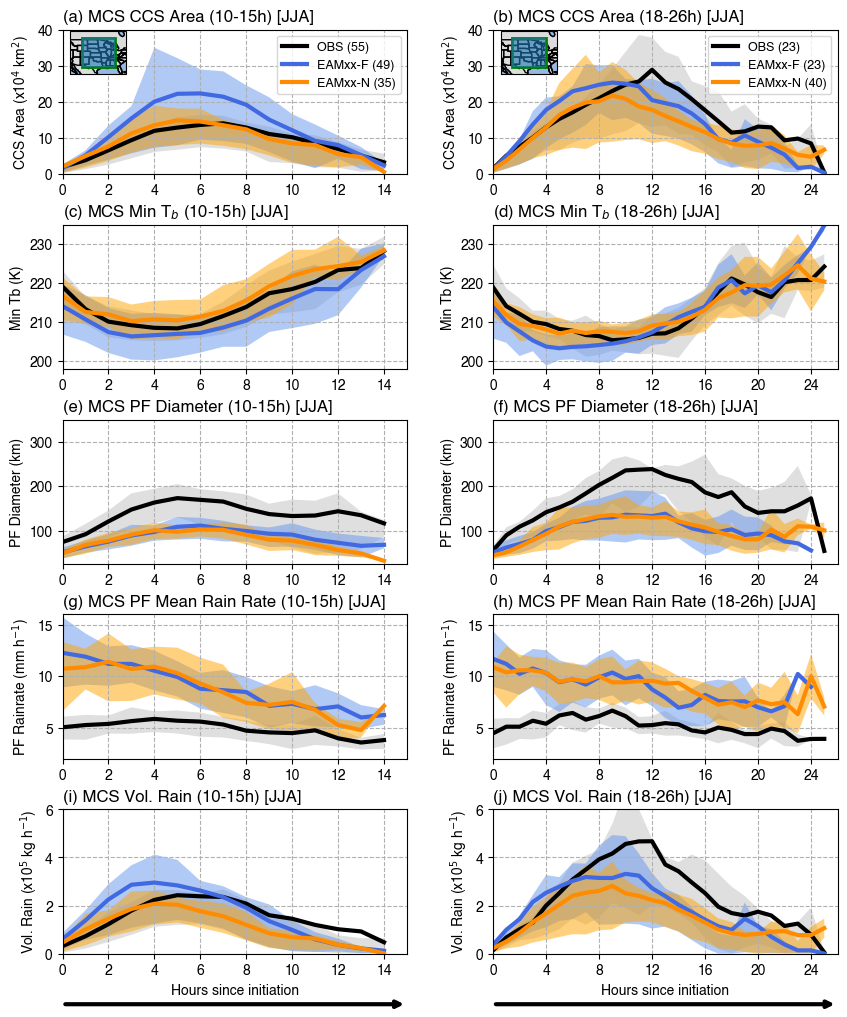

In [93]:
hours_obs = [avg1_ccsarea_l_obs_JJA.times * time_res_obs, avg2_ccsarea_l_obs_JJA.times * time_res_obs]
hours_m1 = [avg1_ccsarea_l_m1_JJA.times * time_res_m1, avg2_ccsarea_l_m1_JJA.times * time_res_m1]
hours_m2 = [avg1_ccsarea_l_m2_JJA.times * time_res_m2, avg2_ccsarea_l_m2_JJA.times * time_res_m2]
dataavg_obs = [[avg1_ccsarea_l_obs_JJA/1e4, avg2_ccsarea_l_obs_JJA/1e4],
            [avg1_mintb_l_obs_JJA, avg2_mintb_l_obs_JJA],
            [avg1_pfdiam_l_obs_JJA, avg2_pfdiam_l_obs_JJA], 
            [avg1_pfrainrate_l_obs_JJA, avg2_pfrainrate_l_obs_JJA],
            [avg1_pfvolrain_l_obs_JJA/1e5, avg2_pfvolrain_l_obs_JJA/1e5]]
dataavg_m1 = [[avg1_ccsarea_l_m1_JJA/1e4, avg2_ccsarea_l_m1_JJA/1e4],
            [avg1_mintb_l_m1_JJA, avg2_mintb_l_m1_JJA],
            [avg1_pfdiam_l_m1_JJA, avg2_pfdiam_l_m1_JJA], 
            [avg1_pfrainrate_l_m1_JJA, avg2_pfrainrate_l_m1_JJA],
            [avg1_pfvolrain_l_m1_JJA/1e5, avg2_pfvolrain_l_m1_JJA/1e5]]
dataavg_m2 = [[avg1_ccsarea_l_m2_JJA/1e4, avg2_ccsarea_l_m2_JJA/1e4],
            [avg1_mintb_l_m2_JJA, avg2_mintb_l_m2_JJA],
            [avg1_pfdiam_l_m2_JJA, avg2_pfdiam_l_m2_JJA], 
            [avg1_pfrainrate_l_m2_JJA, avg2_pfrainrate_l_m2_JJA],
            [avg1_pfvolrain_l_m2_JJA/1e5, avg2_pfvolrain_l_m2_JJA/1e5]]
dataqntl_obs = [[(qntl1_ccsarea_l_obs_JJA.sel(quantile=0.25)/1e4,qntl1_ccsarea_l_obs_JJA.sel(quantile=0.75)/1e4), 
                 (qntl2_ccsarea_l_obs_JJA.sel(quantile=0.25)/1e4,qntl2_ccsarea_l_obs_JJA.sel(quantile=0.75)/1e4)],
                [(qntl1_mintb_l_obs_JJA.sel(quantile=0.25),qntl1_mintb_l_obs_JJA.sel(quantile=0.75)), 
                 (qntl2_mintb_l_obs_JJA.sel(quantile=0.25),qntl2_mintb_l_obs_JJA.sel(quantile=0.75))],
                [(qntl1_pfdiam_l_obs_JJA.sel(quantile=0.25),qntl1_pfdiam_l_obs_JJA.sel(quantile=0.75)), 
                 (qntl2_pfdiam_l_obs_JJA.sel(quantile=0.25),qntl2_pfdiam_l_obs_JJA.sel(quantile=0.75))],
                [(qntl1_pfrainrate_l_obs_JJA.sel(quantile=0.25),qntl1_pfrainrate_l_obs_JJA.sel(quantile=0.75)), 
                 (qntl2_pfrainrate_l_obs_JJA.sel(quantile=0.25),qntl2_pfrainrate_l_obs_JJA.sel(quantile=0.75))],
                [(qntl1_pfvolrain_l_obs_JJA.sel(quantile=0.25)/1e5,qntl1_pfvolrain_l_obs_JJA.sel(quantile=0.75)/1e5), 
                 (qntl2_pfvolrain_l_obs_JJA.sel(quantile=0.25)/1e5,qntl2_pfvolrain_l_obs_JJA.sel(quantile=0.75)/1e5)],]
dataqntl_m1 = [[(qntl1_ccsarea_l_m1_JJA.sel(quantile=0.25)/1e4,qntl1_ccsarea_l_m1_JJA.sel(quantile=0.75)/1e4), 
                 (qntl2_ccsarea_l_m1_JJA.sel(quantile=0.25)/1e4,qntl2_ccsarea_l_m1_JJA.sel(quantile=0.75)/1e4)],
                [(qntl1_mintb_l_m1_JJA.sel(quantile=0.25),qntl1_mintb_l_m1_JJA.sel(quantile=0.75)), 
                 (qntl2_mintb_l_m1_JJA.sel(quantile=0.25),qntl2_mintb_l_m1_JJA.sel(quantile=0.75))],
                [(qntl1_pfdiam_l_m1_JJA.sel(quantile=0.25),qntl1_pfdiam_l_m1_JJA.sel(quantile=0.75)), 
                 (qntl2_pfdiam_l_m1_JJA.sel(quantile=0.25),qntl2_pfdiam_l_m1_JJA.sel(quantile=0.75))],
                [(qntl1_pfrainrate_l_m1_JJA.sel(quantile=0.25),qntl1_pfrainrate_l_m1_JJA.sel(quantile=0.75)), 
                 (qntl2_pfrainrate_l_m1_JJA.sel(quantile=0.25),qntl2_pfrainrate_l_m1_JJA.sel(quantile=0.75))],
                [(qntl1_pfvolrain_l_m1_JJA.sel(quantile=0.25)/1e5,qntl1_pfvolrain_l_m1_JJA.sel(quantile=0.75)/1e5), 
                 (qntl2_pfvolrain_l_m1_JJA.sel(quantile=0.25)/1e5,qntl2_pfvolrain_l_m1_JJA.sel(quantile=0.75)/1e5)],]
dataqntl_m2 = [[(qntl1_ccsarea_l_m2_JJA.sel(quantile=0.25)/1e4,qntl1_ccsarea_l_m2_JJA.sel(quantile=0.75)/1e4), 
                 (qntl2_ccsarea_l_m2_JJA.sel(quantile=0.25)/1e4,qntl2_ccsarea_l_m2_JJA.sel(quantile=0.75)/1e4)],
                [(qntl1_mintb_l_m2_JJA.sel(quantile=0.25),qntl1_mintb_l_m2_JJA.sel(quantile=0.75)), 
                 (qntl2_mintb_l_m2_JJA.sel(quantile=0.25),qntl2_mintb_l_m2_JJA.sel(quantile=0.75))],
                [(qntl1_pfdiam_l_m2_JJA.sel(quantile=0.25),qntl1_pfdiam_l_m2_JJA.sel(quantile=0.75)), 
                 (qntl2_pfdiam_l_m2_JJA.sel(quantile=0.25),qntl2_pfdiam_l_m2_JJA.sel(quantile=0.75))],
                [(qntl1_pfrainrate_l_m2_JJA.sel(quantile=0.25),qntl1_pfrainrate_l_m2_JJA.sel(quantile=0.75)), 
                 (qntl2_pfrainrate_l_m2_JJA.sel(quantile=0.25),qntl2_pfrainrate_l_m2_JJA.sel(quantile=0.75))],
                [(qntl1_pfvolrain_l_m2_JJA.sel(quantile=0.25)/1e5,qntl1_pfvolrain_l_m2_JJA.sel(quantile=0.75)/1e5), 
                 (qntl2_pfvolrain_l_m2_JJA.sel(quantile=0.25)/1e5,qntl2_pfvolrain_l_m2_JJA.sel(quantile=0.75)/1e5)],]
ns_obs = [ns1_l_obs_JJA, ns2_l_obs_JJA]
ns_m1 = [ns1_l_m1_JJA, ns2_l_m1_JJA]
ns_m2 = [ns1_l_m2_JJA, ns2_l_m2_JJA]
titles = []
titles = [[f'(a) MCS CCS Area ({lifetime_range1[0]}-{lifetime_range1[1]}h) [JJA]', f'(b) MCS CCS Area ({lifetime_range2[0]}-{lifetime_range2[1]}h) [JJA]'],
          [f'(c) MCS Min T$_b$ ({lifetime_range1[0]}-{lifetime_range1[1]}h) [JJA]', f'(d) MCS Min T$_b$ ({lifetime_range2[0]}-{lifetime_range2[1]}h) [JJA]'],
          [f'(e) MCS PF Diameter ({lifetime_range1[0]}-{lifetime_range1[1]}h) [JJA]', f'(f) MCS PF Diameter ({lifetime_range2[0]}-{lifetime_range2[1]}h) [JJA]'],
          [f'(g) MCS PF Mean Rain Rate ({lifetime_range1[0]}-{lifetime_range1[1]}h) [JJA]', f'(h) MCS PF Mean Rain Rate ({lifetime_range2[0]}-{lifetime_range2[1]}h) [JJA]'],
          [f'(i) MCS Vol. Rain ({lifetime_range1[0]}-{lifetime_range1[1]}h) [JJA]', f'(j) MCS Vol. Rain ({lifetime_range2[0]}-{lifetime_range2[1]}h) [JJA]']]
xlabels = ['','','','','Hours since initiation']
ylabels = ['CCS Area (x10$^{4}$ km$^2$)', 'Min Tb (K)', 'PF Diameter (km)', 'PF Rainrate (mm h$^{-1}$)', 'Vol. Rain (x10$^{5}$ kg h$^{-1}$)', ]
xticks = [np.arange(0, max(lifetime_range1)+1, 2), np.arange(0, max(lifetime_range2)+1, 4)]
xlims = [(0, max(lifetime_range1)), (0, max(lifetime_range2))]
#ylims = [(0,25), (190,235), (20,250), (2,14), (0,5)]
ylims = [(0,40), (198,235), (25,350), (2,16), (0,6)]
alpha = 0.5
legends = [{'obs':f"{name_map2['obs']} ({ns1_l_obs_JJA})", 'm1':f"{name_map2['m1']} ({ns1_l_m1_JJA})", 'm2':f"{name_map2['m2']} ({ns1_l_m2_JJA})"}, 
           {'obs':f"{name_map2['obs']} ({ns2_l_obs_JJA})", 'm1':f"{name_map2['m1']} ({ns2_l_m1_JJA})", 'm2':f"{name_map2['m2']} ({ns2_l_m2_JJA})"}]
figname = f'{figdir}mcs_composite_evolution_{region}_JJA.png'

bounds = [lon_bounds[0], lon_bounds[1]-0.1, lat_bounds[0], lat_bounds[1]]
map_extent = [bounds[0]-8,bounds[1]+8,bounds[2]-5,bounds[3]+5]
inset_param = {'width':'20%', 'height':'30%', 'loc':'upper left', 'borderpad':0.1}

fig = plot_evolution_mxn(5, 2, hours_obs, hours_m1, hours_m2, dataavg_obs, dataqntl_obs, dataavg_m1, dataqntl_m1, dataavg_m2, dataqntl_m2, ns_obs, ns_m1, ns_m2,
                          titles=titles, xlabels=xlabels, ylabels=ylabels, xticks=xticks, xlims=xlims, ylims=ylims, legends=legends, 
                          map_extent=map_extent, lon_bounds=lon_bounds, lat_bounds=lat_bounds, inset_param=inset_param, figname=figname, figsize=[10,12],
                          fontsize=10, legend_fontsize=9, legend_loc='upper right', alpha=alpha)

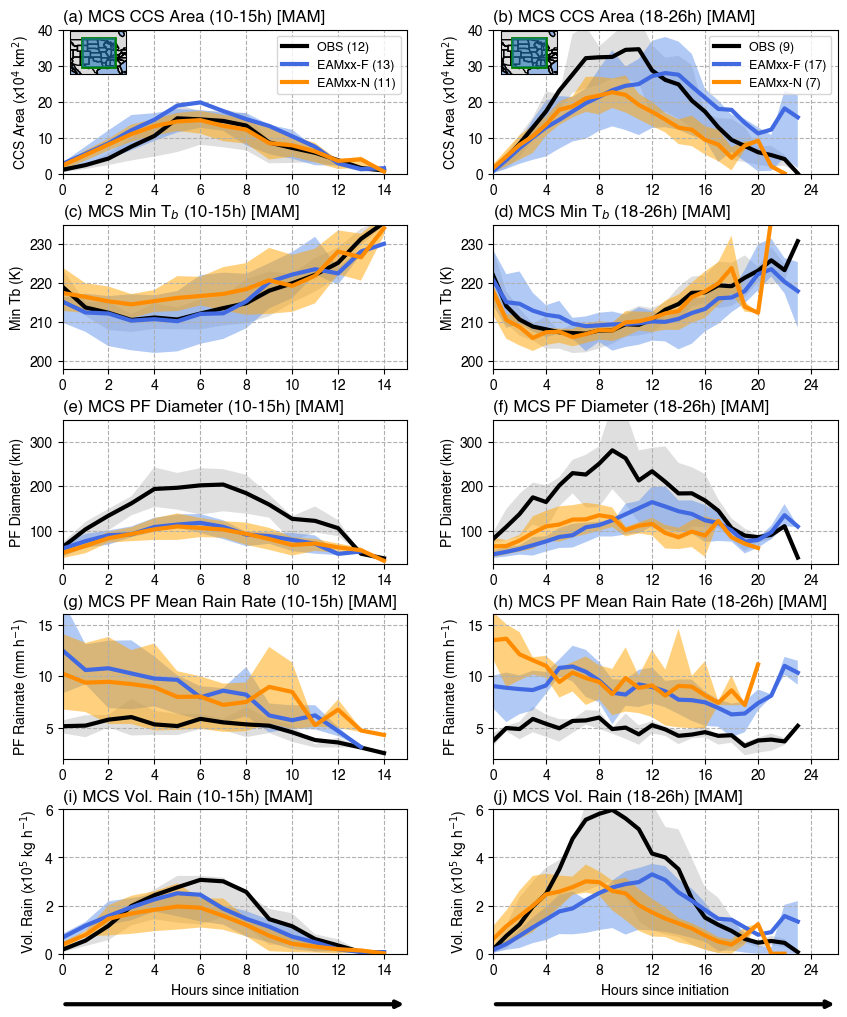

In [94]:
hours_obs = [avg1_ccsarea_l_obs_MAM.times * time_res_obs, avg2_ccsarea_l_obs_MAM.times * time_res_obs]
hours_m1 = [avg1_ccsarea_l_m1_MAM.times * time_res_m1, avg2_ccsarea_l_m1_MAM.times * time_res_m1]
hours_m2 = [avg1_ccsarea_l_m2_MAM.times * time_res_m2, avg2_ccsarea_l_m2_MAM.times * time_res_m2]
dataavg_obs = [[avg1_ccsarea_l_obs_MAM/1e4, avg2_ccsarea_l_obs_MAM/1e4],
            [avg1_mintb_l_obs_MAM, avg2_mintb_l_obs_MAM],
            [avg1_pfdiam_l_obs_MAM, avg2_pfdiam_l_obs_MAM], 
            [avg1_pfrainrate_l_obs_MAM, avg2_pfrainrate_l_obs_MAM],
            [avg1_pfvolrain_l_obs_MAM/1e5, avg2_pfvolrain_l_obs_MAM/1e5]]
dataavg_m1 = [[avg1_ccsarea_l_m1_MAM/1e4, avg2_ccsarea_l_m1_MAM/1e4],
            [avg1_mintb_l_m1_MAM, avg2_mintb_l_m1_MAM],
            [avg1_pfdiam_l_m1_MAM, avg2_pfdiam_l_m1_MAM], 
            [avg1_pfrainrate_l_m1_MAM, avg2_pfrainrate_l_m1_MAM],
            [avg1_pfvolrain_l_m1_MAM/1e5, avg2_pfvolrain_l_m1_MAM/1e5]]
dataavg_m2 = [[avg1_ccsarea_l_m2_MAM/1e4, avg2_ccsarea_l_m2_MAM/1e4],
            [avg1_mintb_l_m2_MAM, avg2_mintb_l_m2_MAM],
            [avg1_pfdiam_l_m2_MAM, avg2_pfdiam_l_m2_MAM], 
            [avg1_pfrainrate_l_m2_MAM, avg2_pfrainrate_l_m2_MAM],
            [avg1_pfvolrain_l_m2_MAM/1e5, avg2_pfvolrain_l_m2_MAM/1e5]]
dataqntl_obs = [[(qntl1_ccsarea_l_obs_MAM.sel(quantile=0.25)/1e4,qntl1_ccsarea_l_obs_MAM.sel(quantile=0.75)/1e4), 
                 (qntl2_ccsarea_l_obs_MAM.sel(quantile=0.25)/1e4,qntl2_ccsarea_l_obs_MAM.sel(quantile=0.75)/1e4)],
                [(qntl1_mintb_l_obs_MAM.sel(quantile=0.25),qntl1_mintb_l_obs_MAM.sel(quantile=0.75)), 
                 (qntl2_mintb_l_obs_MAM.sel(quantile=0.25),qntl2_mintb_l_obs_MAM.sel(quantile=0.75))],
                [(qntl1_pfdiam_l_obs_MAM.sel(quantile=0.25),qntl1_pfdiam_l_obs_MAM.sel(quantile=0.75)), 
                 (qntl2_pfdiam_l_obs_MAM.sel(quantile=0.25),qntl2_pfdiam_l_obs_MAM.sel(quantile=0.75))],
                [(qntl1_pfrainrate_l_obs_MAM.sel(quantile=0.25),qntl1_pfrainrate_l_obs_MAM.sel(quantile=0.75)), 
                 (qntl2_pfrainrate_l_obs_MAM.sel(quantile=0.25),qntl2_pfrainrate_l_obs_MAM.sel(quantile=0.75))],
                [(qntl1_pfvolrain_l_obs_MAM.sel(quantile=0.25)/1e5,qntl1_pfvolrain_l_obs_MAM.sel(quantile=0.75)/1e5), 
                 (qntl2_pfvolrain_l_obs_MAM.sel(quantile=0.25)/1e5,qntl2_pfvolrain_l_obs_MAM.sel(quantile=0.75)/1e5)],]
dataqntl_m1 = [[(qntl1_ccsarea_l_m1_MAM.sel(quantile=0.25)/1e4,qntl1_ccsarea_l_m1_MAM.sel(quantile=0.75)/1e4), 
                 (qntl2_ccsarea_l_m1_MAM.sel(quantile=0.25)/1e4,qntl2_ccsarea_l_m1_MAM.sel(quantile=0.75)/1e4)],
                [(qntl1_mintb_l_m1_MAM.sel(quantile=0.25),qntl1_mintb_l_m1_MAM.sel(quantile=0.75)), 
                 (qntl2_mintb_l_m1_MAM.sel(quantile=0.25),qntl2_mintb_l_m1_MAM.sel(quantile=0.75))],
                [(qntl1_pfdiam_l_m1_MAM.sel(quantile=0.25),qntl1_pfdiam_l_m1_MAM.sel(quantile=0.75)), 
                 (qntl2_pfdiam_l_m1_MAM.sel(quantile=0.25),qntl2_pfdiam_l_m1_MAM.sel(quantile=0.75))],
                [(qntl1_pfrainrate_l_m1_MAM.sel(quantile=0.25),qntl1_pfrainrate_l_m1_MAM.sel(quantile=0.75)), 
                 (qntl2_pfrainrate_l_m1_MAM.sel(quantile=0.25),qntl2_pfrainrate_l_m1_MAM.sel(quantile=0.75))],
                [(qntl1_pfvolrain_l_m1_MAM.sel(quantile=0.25)/1e5,qntl1_pfvolrain_l_m1_MAM.sel(quantile=0.75)/1e5), 
                 (qntl2_pfvolrain_l_m1_MAM.sel(quantile=0.25)/1e5,qntl2_pfvolrain_l_m1_MAM.sel(quantile=0.75)/1e5)],]
dataqntl_m2 = [[(qntl1_ccsarea_l_m2_MAM.sel(quantile=0.25)/1e4,qntl1_ccsarea_l_m2_MAM.sel(quantile=0.75)/1e4), 
                 (qntl2_ccsarea_l_m2_MAM.sel(quantile=0.25)/1e4,qntl2_ccsarea_l_m2_MAM.sel(quantile=0.75)/1e4)],
                [(qntl1_mintb_l_m2_MAM.sel(quantile=0.25),qntl1_mintb_l_m2_MAM.sel(quantile=0.75)), 
                 (qntl2_mintb_l_m2_MAM.sel(quantile=0.25),qntl2_mintb_l_m2_MAM.sel(quantile=0.75))],
                [(qntl1_pfdiam_l_m2_MAM.sel(quantile=0.25),qntl1_pfdiam_l_m2_MAM.sel(quantile=0.75)), 
                 (qntl2_pfdiam_l_m2_MAM.sel(quantile=0.25),qntl2_pfdiam_l_m2_MAM.sel(quantile=0.75))],
                [(qntl1_pfrainrate_l_m2_MAM.sel(quantile=0.25),qntl1_pfrainrate_l_m2_MAM.sel(quantile=0.75)), 
                 (qntl2_pfrainrate_l_m2_MAM.sel(quantile=0.25),qntl2_pfrainrate_l_m2_MAM.sel(quantile=0.75))],
                [(qntl1_pfvolrain_l_m2_MAM.sel(quantile=0.25)/1e5,qntl1_pfvolrain_l_m2_MAM.sel(quantile=0.75)/1e5), 
                 (qntl2_pfvolrain_l_m2_MAM.sel(quantile=0.25)/1e5,qntl2_pfvolrain_l_m2_MAM.sel(quantile=0.75)/1e5)],]
ns_obs = [ns1_l_obs_MAM, ns2_l_obs_MAM]
ns_m1 = [ns1_l_m1_MAM, ns2_l_m1_MAM]
ns_m2 = [ns1_l_m2_MAM, ns2_l_m2_MAM]
titles = []
titles = [[f'(a) MCS CCS Area ({lifetime_range1[0]}-{lifetime_range1[1]}h) [MAM]', f'(b) MCS CCS Area ({lifetime_range2[0]}-{lifetime_range2[1]}h) [MAM]'],
          [f'(c) MCS Min T$_b$ ({lifetime_range1[0]}-{lifetime_range1[1]}h) [MAM]', f'(d) MCS Min T$_b$ ({lifetime_range2[0]}-{lifetime_range2[1]}h) [MAM]'],
          [f'(e) MCS PF Diameter ({lifetime_range1[0]}-{lifetime_range1[1]}h) [MAM]', f'(f) MCS PF Diameter ({lifetime_range2[0]}-{lifetime_range2[1]}h) [MAM]'],
          [f'(g) MCS PF Mean Rain Rate ({lifetime_range1[0]}-{lifetime_range1[1]}h) [MAM]', f'(h) MCS PF Mean Rain Rate ({lifetime_range2[0]}-{lifetime_range2[1]}h) [MAM]'],
          [f'(i) MCS Vol. Rain ({lifetime_range1[0]}-{lifetime_range1[1]}h) [MAM]', f'(j) MCS Vol. Rain ({lifetime_range2[0]}-{lifetime_range2[1]}h) [MAM]']]
xlabels = ['','','','','Hours since initiation']
ylabels = ['CCS Area (x10$^{4}$ km$^2$)', 'Min Tb (K)', 'PF Diameter (km)', 'PF Rainrate (mm h$^{-1}$)', 'Vol. Rain (x10$^{5}$ kg h$^{-1}$)', ]
xticks = [np.arange(0, max(lifetime_range1)+1, 2), np.arange(0, max(lifetime_range2)+1, 4)]
xlims = [(0, max(lifetime_range1)), (0, max(lifetime_range2))]
#ylims = [(0,25), (190,235), (20,250), (2,14), (0,5)]
ylims = [(0,40), (198,235), (25,350), (2,16), (0,6)]
alpha = 0.5
legends = [{'obs':f"{name_map2['obs']} ({ns1_l_obs_MAM})", 'm1':f"{name_map2['m1']} ({ns1_l_m1_MAM})", 'm2':f"{name_map2['m2']} ({ns1_l_m2_MAM})"}, 
           {'obs':f"{name_map2['obs']} ({ns2_l_obs_MAM})", 'm1':f"{name_map2['m1']} ({ns2_l_m1_MAM})", 'm2':f"{name_map2['m2']} ({ns2_l_m2_MAM})"}]
figname = f'{figdir}mcs_composite_evolution_{region}_MAM.png'

bounds = [lon_bounds[0], lon_bounds[1]-0.1, lat_bounds[0], lat_bounds[1]]
map_extent = [bounds[0]-8,bounds[1]+8,bounds[2]-5,bounds[3]+5]
inset_param = {'width':'20%', 'height':'30%', 'loc':'upper left', 'borderpad':0.1}

fig = plot_evolution_mxn(5, 2, hours_obs, hours_m1, hours_m2, dataavg_obs, dataqntl_obs, dataavg_m1, dataqntl_m1, dataavg_m2, dataqntl_m2, ns_obs, ns_m1, ns_m2,
                          titles=titles, xlabels=xlabels, ylabels=ylabels, xticks=xticks, xlims=xlims, ylims=ylims, legends=legends, 
                          map_extent=map_extent, lon_bounds=lon_bounds, lat_bounds=lat_bounds, inset_param=inset_param, figname=figname, figsize=[10,12],
                          fontsize=10, legend_fontsize=9, legend_loc='upper right', alpha=alpha)

In [66]:
figdir

'/global/cfs/cdirs/m1867/www/PyFLEXTRKR/sample_data/TGW_MCS/figures/'

In [67]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

## Set Seaborn plot style

In [192]:
# sns.set_theme('talk', style='whitegrid', font_scale=1.3, 
#               rc={'lines.linewidth':5, 'font.family':'Helvetica', 'axes.edgecolor':'k', 'grid.linestyle':'--'})
# sns.axes_style()

## Function to plot 2D KDE

In [193]:
def plot_jointdist(x_obs, y_obs, x_m1, y_m1, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   legend_loc='lower right', legend_labels=None):
#    mpl.rcParams['font.family'] = 'Helvetica'
    g = sns.JointGrid(height=8, ratio=5, space=.3, marginal_ticks=False, xlim=xlim, ylim=ylim)

    lcolors = {'obs':'steelblue', 'model':'darkorange'}
    # cmap = copy.copy(mpl.cm.get_cmap('Blues'))
    cmap = copy.copy(mpl.colormaps.get_cmap('Blues'))
    cmap = truncate_colormap(cmap, 0.1, 1)
    sns.kdeplot(x=x_obs, y=y_obs, levels=levels, fill=True, cmap=cmap, alpha=0.9, ax=g.ax_joint)
    sns.kdeplot(x=x_m1, y=y_m1, color=lcolors['model'], levels=levels, fill=False, ax=g.ax_joint)
    sns.kdeplot(x=x_obs, color=lcolors['obs'], ax=g.ax_marg_x)
    sns.kdeplot(x=x_m1, color=lcolors['model'], ax=g.ax_marg_x)
    sns.kdeplot(y=y_obs, color=lcolors['obs'], ax=g.ax_marg_y)
    sns.kdeplot(y=y_m1, color=lcolors['model'], ax=g.ax_marg_y)
    legend_elements = [mpl.patches.Patch(facecolor=lcolors['obs'], edgecolor='b'),
                       mpl.lines.Line2D([0], [0], color=lcolors['model'])]
    # legend_labels = ['OBS', f'{model_name[name_map["m1"]]}']
    leg = mpl.legend.Legend(g.ax_joint, handles=legend_elements, labels=legend_labels, 
                            loc=legend_loc, facecolor='w', prop={'family':'Helvetica', 'size':18})
    g.ax_joint.text(0.95, 0.95, annotate_text, ha='right', va='center', transform=g.ax_joint.transAxes)
    g.ax_joint.add_artist(leg)
    g.set_axis_labels(xlabel=xlabel, ylabel=ylabel)
    g.ax_marg_x.set_ylabel('')
    g.ax_marg_y.set_xlabel('')

    g.savefig(figname, dpi=300, facecolor='w')
    # sns.JointGrid(marginal_ticks=True)
    return g

## Land

In [194]:
levels = [0.1,0.2,0.4,0.6,0.8,1]
legend_labels = ['OBS', 'EAMxx-F', 'EAMxx-N']
# annotate_text = f'{region} (Land)'

In [195]:
ccslifetime_l_obs_JJA.shape, pfvolrain_l_obs_JJA.sum(dim='times').shape

((126,), (126,))

In [196]:
# x_obs, y_obs = ccslifetime_l_obs_JJA.data, np.log10(pfvolrain_l_obs_JJA.sum(dim='times')).data
# x_m1, y_m1 = ccslifetime_l_m1_JJA.data, np.log10(pfvolrain_l_m1_JJA.sum(dim='times')).data
# xlim = (0,100)
# ylim = (4.0,8.0)
# xlabel = 'MCS Lifetime [hour]'
# ylabel = 'Log$_{10}$(Total Vol. Rain [kg])'
# annotate_text = f'{region} (JJA)'
# figname = f'{figdir}JointDist_Lifetime_Totalvolrain_{region}_obs_wrf_JJA.png'
# g = plot_jointdist(x_obs, y_obs, x_m1, y_m1, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, legend_labels=legend_labels)

In [197]:
# x_obs, y_obs = ccslifetime_l_obs_JJA.data, np.log10(ds_nms_l_obs.pf_area.max(dim=('times','nmaxpf')).where(start_season_obs == 'JJA', drop=True)).data
# x_m1, y_m1 = ccslifetime_l_m1_JJA.data, np.log10(ds_nms_l_m1.pf_area.max(dim=('times','nmaxpf')).where(start_season_m1 == 'JJA', drop=True)).data
# xlim = (0,100)
# ylim = (3.5,6.1)
# xlabel = 'MCS Lifetime [hour]'
# ylabel = 'Log$_{10}$(Max PF Area [km$^2$])'
# annotate_text = f'{region} (JJA)'
# figname = f'{figdir}JointDist_Lifetime_PFarea_{region}_obs_wrf_JJA.png'
# g = plot_jointdist(x_obs, y_obs, x_m1, y_m1, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, legend_labels=legend_labels)

In [198]:
# x_obs = ds_nms_l_obs.corecold_mintb.mean(dim='times').where(start_season_obs == 'JJA', drop=True).data
# y_obs = np.log10(ds_nms_l_obs.total_heavyrain.sum(dim='times').where(start_season_obs == 'JJA', drop=True) * pixel_radius_obs**2)
# x_m1 = ds_nms_l_m1.corecold_mintb.mean(dim='times').where(start_season_m1 == 'JJA', drop=True).data
# y_m1 = np.log10(ds_nms_l_m1.total_heavyrain.sum(dim='times').where(start_season_m1 == 'JJA', drop=True) * pixel_radius_m1**2)
# xlim = (200,240)
# ylim = (4.,8)
# xlabel = 'Average Min T$_b$ [K]'
# ylabel = 'Log$_{10}$(Heavy Vol. Rain [kg])'
# annotate_text = f'{region} (JJA)'
# figname = f'{figdir}JointDist_MinTb_HeavyVolrain_{region}_obs_wrf_JJA.png'
# g = plot_jointdist(x_obs, y_obs, x_m1, y_m1, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, legend_labels=legend_labels)

In [199]:
# # Largest PF mean rain rate vs. Heavy Rain Volume
# x_obs = ds_nms_l_obs.pf_rainrate.isel(nmaxpf=0).mean(dim='times').where(start_season_obs == 'JJA', drop=True).data
# y_obs = np.log10(ds_nms_l_obs.total_heavyrain.sum(dim='times').where(start_season_obs == 'JJA', drop=True) * pixel_radius_obs**2)
# x_m1 = ds_nms_l_m1.pf_rainrate.isel(nmaxpf=0).mean(dim='times').where(start_season_obs == 'JJA', drop=True).data
# y_m1 = np.log10(ds_nms_l_m1.total_heavyrain.sum(dim='times').where(start_season_obs == 'JJA', drop=True) * pixel_radius_m1**2)
# xlim = (0,5)
# ylim = (4,8)
# xlabel = 'Mean PF Rain Rate [mm h$^{-1}$]'
# ylabel = 'Log$_{10}$(Heavy Vol. Rain [kg])'
# annotate_text = f'{region} (JJA)'
# figname = f'{figdir}JointDist_PFrainrate_HeavyVolrain_{region}_obs_wrf_JJA.png'
# g = plot_jointdist(x_obs, y_obs, x_m1, y_m1, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, legend_labels=legend_labels)

In [200]:
# # Largest PF mean rain rate vs. Total Rain Volume
# x_obs = ds_nms_l_obs.pf_rainrate.isel(nmaxpf=0).mean(dim='times').where(start_season_obs == 'JJA', drop=True).data
# y_obs = np.log10(ds_nms_l_obs.total_rain.sum(dim='times').where(start_season_obs == 'JJA', drop=True) * pixel_radius_obs**2)
# x_m1 = ds_nms_l_m1.pf_rainrate.isel(nmaxpf=0).mean(dim='times').where(start_season_obs == 'JJA', drop=True).data
# y_m1 = np.log10(ds_nms_l_m1.total_rain.sum(dim='times').where(start_season_obs == 'JJA', drop=True) * pixel_radius_m1**2)
# xlim = (0,5)
# ylim = (4,8)
# xlabel = 'Mean PF Rain Rate [mm h$^{-1}$]'
# ylabel = 'Log$_{10}$(Total Vol. Rain [kg])'
# annotate_text = f'{region} (JJA)'
# figname = f'{figdir}JointDist_PFrainrate_TotalVolrain_{region}_obs_wrf_JJA.png'
# g = plot_jointdist(x_obs, y_obs, x_m1, y_m1, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, legend_labels=legend_labels)

In [201]:
# figdir